<a href="https://colab.research.google.com/github/Ayewa-Ak/Data-Science-Practice-/blob/main/CRM_Segmenntation_Akosua_Ayewa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRM Customer Segmentation
### Italian Food Retail Subsidiary

This notebook delivers a data-driven segmentation of the customer base for the
Italian subsidiary of a leading international food retailer.

**Business objective:** Renew targeted communication programmes by identifying
distinct customer groups that can be reached with tailored campaigns.

**Data:** ~2 years of transactional history across 25,727 registered customers,
490K transaction headers, and 2M+ receipt lines spanning four datasets.

**Approach:** Data audit → Metric definition → Feature engineering →
K-means clustering → Segment profiling → Campaign brief definition

## 1. Setup - Libraries & Data Loading

Import required libraries and load the four raw CSV files from the zipped
source folder. Two files use semicolon separators and are handled accordingly.

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import pandas as pd

In [38]:
import pandas as pd
import os

directory_path = '/content/drive/MyDrive/1_SEGMENTATION'
dataframes = {}

# Iterate over files in the directory
for filename in os.listdir(directory_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(directory_path, filename)
        sep = ';' if filename in ['RETAIL_PRODUCT.csv', 'RETAIL_SALES.csv'] else ','
        try:
            dataframes[filename] = pd.read_csv(file_path, encoding='latin-1', sep=sep)
            print(f"Loaded {filename}")
        except Exception as e:
            print(f"Error loading {filename}: {e}")


print(f"\nSuccessfully loaded dataframes: {dataframes.keys()}")

Loaded RETAIL_PRODUCT.csv
Loaded RETAIL_SALES.csv
Loaded RETAIL_REGISTRY.csv


/tmp/ipykernel_20006/3541042025.py:13: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[filename] = pd.read_csv(file_path, encoding='latin-1', sep=sep)


Loaded RETAIL_SALES_DETAIL.csv

Successfully loaded dataframes: dict_keys(['RETAIL_PRODUCT.csv', 'RETAIL_SALES.csv', 'RETAIL_REGISTRY.csv', 'RETAIL_SALES_DETAIL.csv'])


In [39]:
df = pd.DataFrame

df_retail_products = dataframes["RETAIL_PRODUCT.csv"]
df_retail_registry = dataframes["RETAIL_REGISTRY.csv"]
df_retail_sales = dataframes["RETAIL_SALES.csv"]
df_retail_sales_detail = dataframes["RETAIL_SALES_DETAIL.csv"]


## 2. Data Exploration

Initial exploration of the four datasets to understand their structure,
dimensions, and content before any cleaning or modelling.

We examine column names, shapes, and the first few rows of each dataframe
to confirm correct loading and identify any immediate issues.

In [40]:
dataframes = {
    'df_retail_products': df_retail_products,
    'df_retail_registry': df_retail_registry,
    'df_retail_sales': df_retail_sales,
    'df_retail_sales_detail': df_retail_sales_detail
}
shapes = []
for name, df in dataframes.items():
    shapes.append({
        'DataFrame': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1]
    })

df_shapes = pd.DataFrame(shapes)
df_shapes_desc = df_shapes.sort_values(by='Rows', ascending=False)
df_shapes_desc

,DataFrame,Rows,Columns
3,df_retail_sales_detail,2047073,6
2,df_retail_sales,489967,6
1,df_retail_registry,25727,4
0,df_retail_products,2800,3


In [41]:
#df.columns

for i, df in enumerate([df_retail_products, df_retail_registry, df_retail_sales, df_retail_sales_detail], 1):
    print(f"DataFrame {i} columns:")
    print(df.columns.tolist())
    print(f"Shape: {df.shape}\n")

DataFrame 1 columns:
['PRODUCT_ID', 'CATEGORY_ID', 'CATEGORY_DESC']
Shape: (2800, 3)

DataFrame 2 columns:
['CUSTOMER_ID', 'CREATION_DATE', 'REGIONAL_CODE', 'ORIGIN']
Shape: (25727, 4)

DataFrame 3 columns:
['CUSTOMER_ID', 'DATE', 'OUTLET_ID', 'PAYMENT_METHOD', 'TIME', 'TOTAL_POINTS']
Shape: (489967, 6)

DataFrame 4 columns:
['CUSTOMER_ID', 'DATE', 'PRODUCT_ID', 'QUANTITY', 'LIST_PRICE', 'SPECIAL']
Shape: (2047073, 6)



In [42]:
#df.head

for i, df in enumerate([df_retail_products, df_retail_registry, df_retail_sales, df_retail_sales_detail], 1):
    print(f"DataFrame {i}:")
    print(df.head())
    print()

DataFrame 1:
   PRODUCT_ID  CATEGORY_ID CATEGORY_DESC
0       92887            4       POULTRY
1      102017            1  OTHER_FROZEN
2      103710            3    READY-MADE
3       10184            7          FISH
4       10328           16         OTHER

DataFrame 2:
  CUSTOMER_ID CREATION_DATE  REGIONAL_CODE ORIGIN
0  AA00312188    2005-11-05             11    WEB
1  AA00312390    2009-01-17             42    WEB
2  AA00325975    2005-01-04             11    WEB
3  AA00336843    2014-03-12             11    WEB
4  AA00339761    2004-02-13              6    WEB

DataFrame 3:
  CUSTOMER_ID        DATE  OUTLET_ID PAYMENT_METHOD      TIME  TOTAL_POINTS
0  AA00312188  2019-02-14         64           CASH  14:39:56         290.0
1  AA00312188  2019-02-28         64           CASH  14:19:14         155.0
2  AA00312188  2019-03-14         64           CASH  14:39:26         295.0
3  AA00312188  2018-09-27         64           CASH  14:53:44         115.0
4  AA00312188  2019-04-25        

### 2.1 Univariate Distributions

We explore the distribution of key numeric and categorical variables across
the raw transaction data before applying any customer-level lens.

Key variables: total points per transaction, quantity per receipt line,
list price, payment method, outlet, and day of week. We plot both raw and
log-transformed versions of skewed numeric variables to assess their shape.


 Total points per transaction (positives only) 
count    442672.00
mean        252.61
std         200.41
min           5.00
25%         125.00
50%         200.00
75%         325.00
95%         630.00
99%         955.00
max        9180.00
Name: TOTAL_POINTS, dtype: float64

 Quantity per receipt line (positives only) 
count    1946523.00
mean           1.14
std            1.75
min            1.00
25%            1.00
50%            1.00
75%            1.00
95%            2.00
99%            3.00
max         1000.00
Name: QUANTITY, dtype: float64

 List price per item (positives only) 
count    1946523.00
mean           8.49
std            5.36
min            0.05
25%            5.25
50%            7.25
75%            9.95
95%           16.95
99%           27.30
max          370.45
Name: LIST_PRICE, dtype: float64

 Line total (price x quantity) 
count    1946523.00
mean          10.75
std           60.04
min            0.05
25%            5.25
50%            7.25
75%           10.95
95%

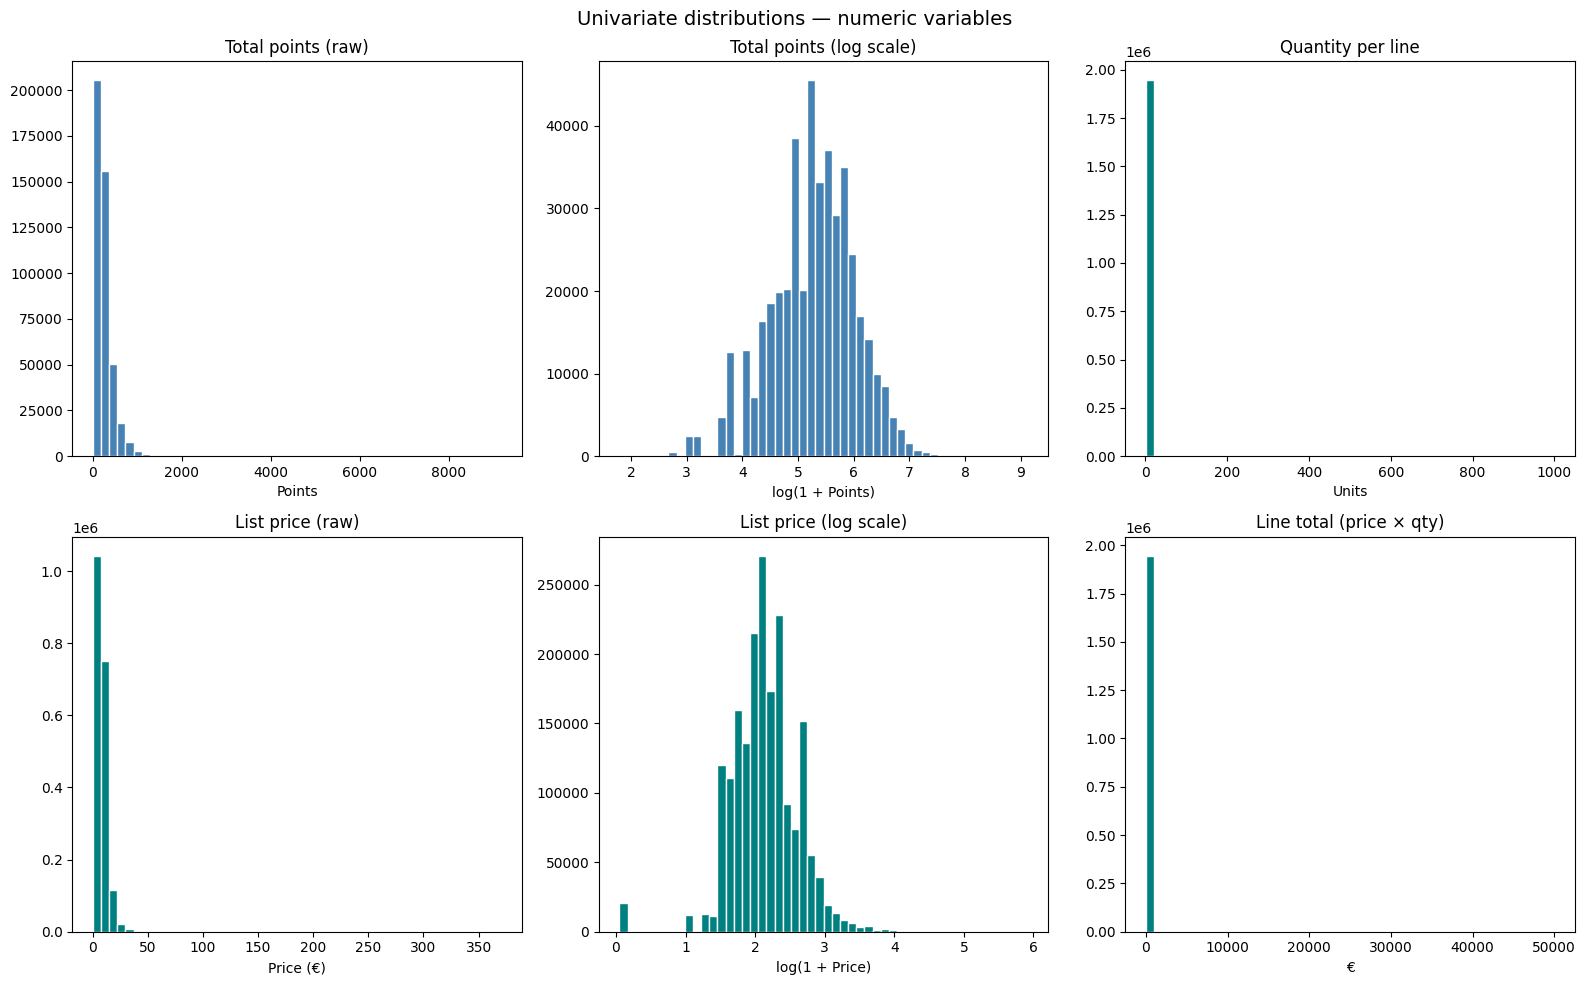

In [43]:
import numpy as np

#Summary statistics helper (handles both numeric and categorical)
def summary_stats(series, name):
    print(f"\n {name} ")
    if pd.api.types.is_numeric_dtype(series):
        print(series.describe(percentiles=[.25, .75, .95, .99]).round(2))
    else:
        print(series.value_counts())

#1: negative values in TOTAL_POINTS, QUANTITY, LIST_PRICE
# Negatives are returns/corrections filter them out for distribution analysis
sales_pos = df_retail_sales[df_retail_sales['TOTAL_POINTS'] > 0]
detail_pos = df_retail_sales_detail[
    (df_retail_sales_detail['QUANTITY'] > 0) &
    (df_retail_sales_detail['LIST_PRICE'] > 0)
]

#: LINE_TOTAL
detail_pos = detail_pos.copy()
detail_pos['LINE_TOTAL'] = detail_pos['LIST_PRICE'] * detail_pos['QUANTITY']

# Numeric distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Univariate distributions - numeric variables", fontsize=14)

# Total points (raw)
summary_stats(sales_pos['TOTAL_POINTS'], 'Total points per transaction (positives only)')
axes[0,0].hist(sales_pos['TOTAL_POINTS'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Total points (raw)')
axes[0,0].set_xlabel('Points')

# Total points (log)
axes[0,1].hist(np.log1p(sales_pos['TOTAL_POINTS'].dropna()), bins=50, color='steelblue', edgecolor='white')
axes[0,1].set_title('Total points (log scale)')
axes[0,1].set_xlabel('log(1 + Points)')

# Quantity per line
summary_stats(detail_pos['QUANTITY'], 'Quantity per receipt line (positives only)')
axes[0,2].hist(detail_pos['QUANTITY'].dropna(), bins=50, color='teal', edgecolor='white')
axes[0,2].set_title('Quantity per line')
axes[0,2].set_xlabel('Units')

# List price (raw)
summary_stats(detail_pos['LIST_PRICE'], 'List price per item (positives only)')
axes[1,0].hist(detail_pos['LIST_PRICE'].dropna(), bins=50, color='teal', edgecolor='white')
axes[1,0].set_title('List price (raw)')
axes[1,0].set_xlabel('Price (€)')

# List price (log)
axes[1,1].hist(np.log1p(detail_pos['LIST_PRICE'].dropna()), bins=50, color='teal', edgecolor='white')
axes[1,1].set_title('List price (log scale)')
axes[1,1].set_xlabel('log(1 + Price)')

# Line total (price x quantity)
summary_stats(detail_pos['LINE_TOTAL'], 'Line total (price x quantity)')
axes[1,2].hist(detail_pos['LINE_TOTAL'].dropna(), bins=50, color='teal', edgecolor='white')
axes[1,2].set_title('Line total (price × qty)')
axes[1,2].set_xlabel('€')

plt.tight_layout()
plt.show()

### 2.2 Temporal Patterns

We analyse purchasing behaviour over time to identify seasonality, trend
breaks, and any suspicious gaps in the data that could distort our metrics.

Plots: monthly transaction volume, day-of-week distribution, hour-of-day
distribution. A COVID reference line is added to the monthly chart given the
2-year observation window spans the 2020 lockdown period.

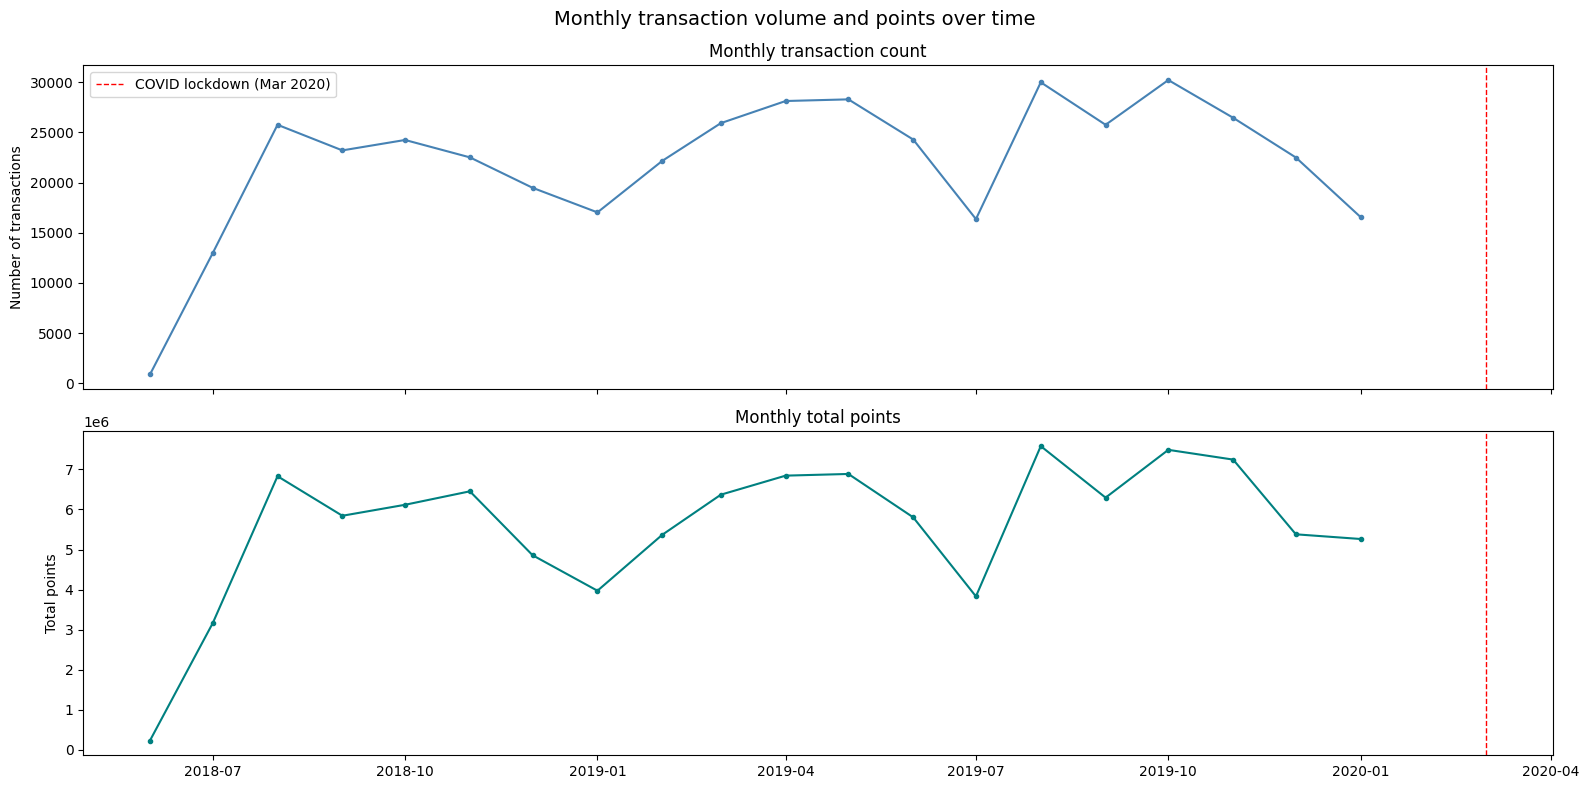

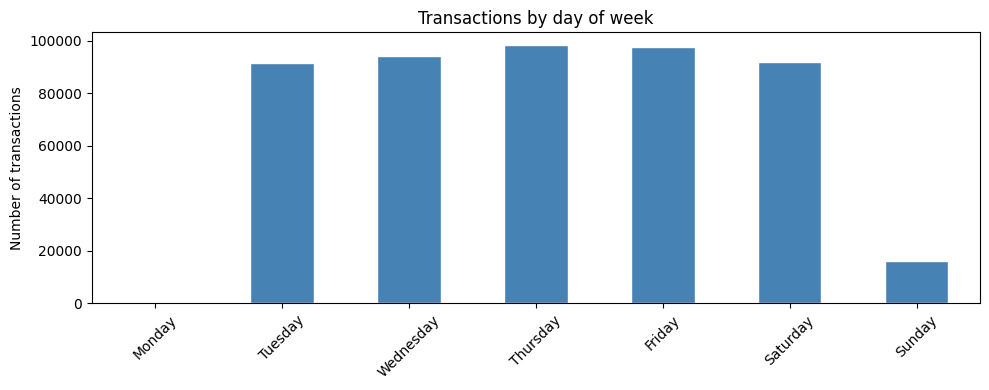

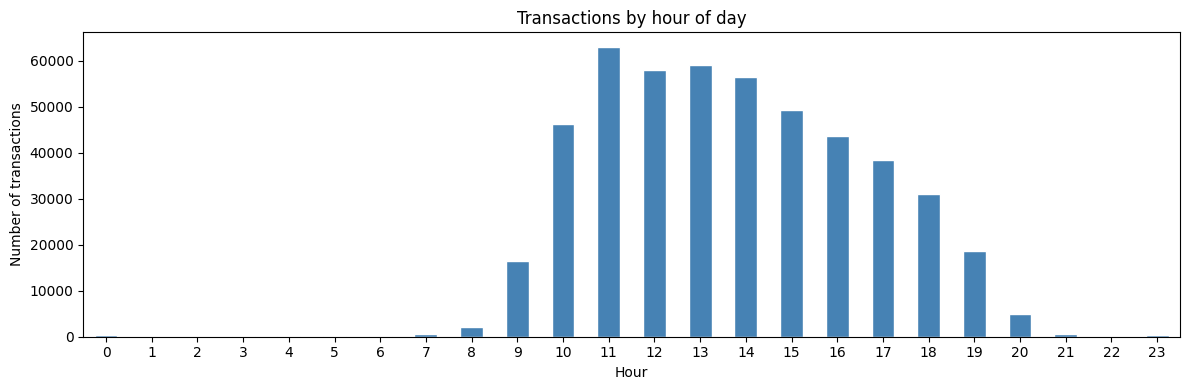

In [44]:

#  Parse dates and extract time components
df_retail_sales['DATE'] = pd.to_datetime(df_retail_sales['DATE'])
df_retail_sales['MONTH']        = df_retail_sales['DATE'].dt.to_period('M')
df_retail_sales['DAY_OF_WEEK']  = df_retail_sales['DATE'].dt.day_name()
df_retail_sales['HOUR']         = pd.to_datetime(df_retail_sales['TIME'], format='%H:%M:%S').dt.hour

#  Monthly volume and points
monthly = df_retail_sales[df_retail_sales['TOTAL_POINTS'] > 0].groupby('MONTH').agg(
    n_transactions = ('CUSTOMER_ID', 'count'),
    total_points   = ('TOTAL_POINTS', 'sum')
).reset_index()
monthly['MONTH_DT'] = monthly['MONTH'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("Monthly transaction volume and points over time", fontsize=14)

axes[0].plot(monthly['MONTH_DT'], monthly['n_transactions'], color='steelblue', marker='o', markersize=3)
axes[0].set_ylabel('Number of transactions')
axes[0].set_title('Monthly transaction count')
axes[0].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=1, label='COVID lockdown (Mar 2020)')
axes[0].legend()

axes[1].plot(monthly['MONTH_DT'], monthly['total_points'], color='teal', marker='o', markersize=3)
axes[1].set_ylabel('Total points')
axes[1].set_title('Monthly total points')
axes[1].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

#  Day-of-week pattern
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df_retail_sales.groupby('DAY_OF_WEEK').size().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 4))
dow.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Transactions by day of week')
ax.set_xlabel('')
ax.set_ylabel('Number of transactions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#  Hour-of-day pattern
hod = df_retail_sales.groupby('HOUR').size()

fig, ax = plt.subplots(figsize=(12, 4))
hod.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Transactions by hour of day')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of transactions')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 2.3 Customer-Level Aggregation

We collapse the transaction log into a single row per customer, computing
the candidate metrics that will drive the segmentation model.

Metrics computed:
- **Recency** - days since last purchase
- **Frequency** - number of visits
- **Total points** - cumulative spend proxy
- **Avg ticket** - average points per visit
- **Outlet HHI** - outlet concentration (Herfindahl index)
- **Avg basket value** - average line total per visit
- **Avg categories per visit** - category breadth
- **Avg promo share** - share of items purchased on promotion

Customer table shape: (25484, 9)

One-timer share: 1.9%

Monetary value — mean: 4388  median: 3205

Customer table preview:
  CUSTOMER_ID  recency  frequency  total_points  avg_ticket  outlet_hhi  \
0  AA00312188       24         24        5960.0  248.333333    0.635417   
1  AA00312390       71         24        2705.0  112.708333    0.920139   
2  AA00325975        1         33       10095.0  305.909091    0.941230   
3  AA00336843       14         21        2800.0  133.333333    0.414966   
4  AA00339761       23         16        3210.0  200.625000    1.000000   

   avg_basket_value  avg_n_categories  avg_promo_share  
0         41.618000          3.080000              0.0  
1         22.931667          1.600000              0.0  
2         39.608571          3.714286              0.0  
3         22.640909          2.136364              0.0  
4         33.811765          2.529412              0.0  


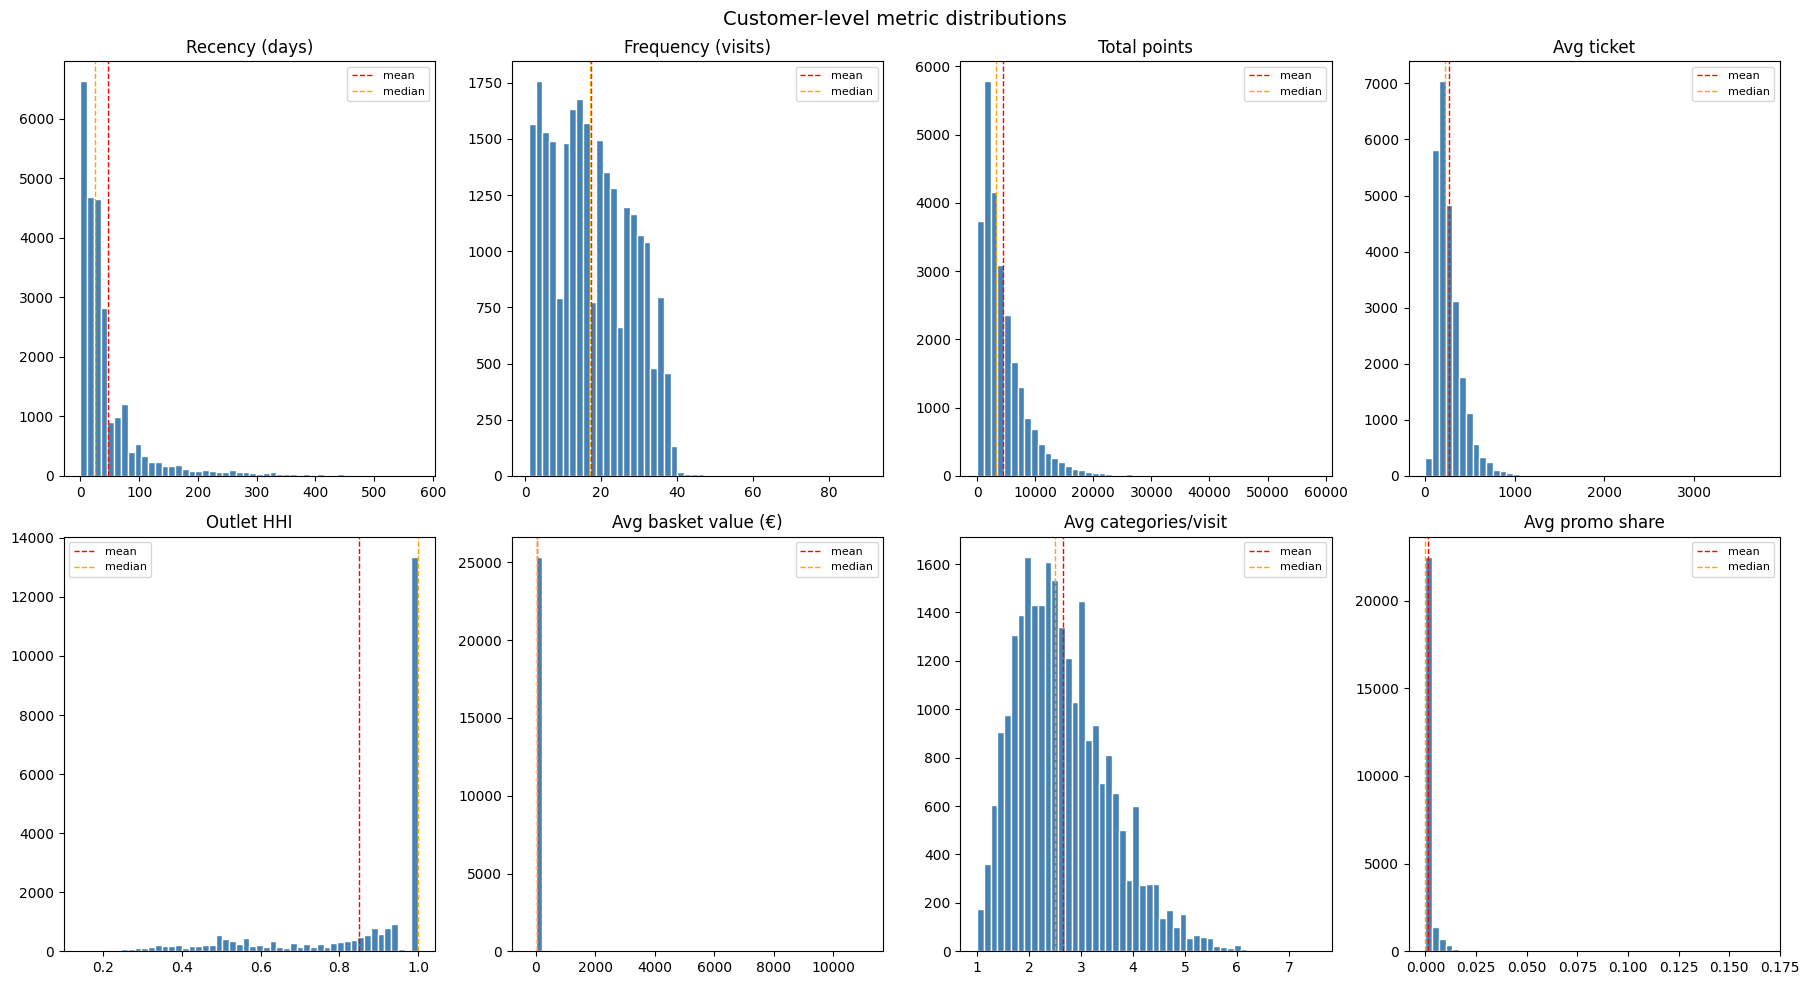


Customer-level summary statistics:
        recency  frequency  total_points  avg_ticket  outlet_hhi  \
count  25484.00   25484.00      25484.00    25484.00    25484.00   
mean      47.53      17.37       4387.92      265.07        0.85   
std       70.88      10.46       4009.86      159.07        0.21   
min        0.00       1.00          5.00        5.00        0.14   
25%       11.00       9.00       1635.00      157.74        0.76   
50%       24.00      17.00       3205.00      225.42        1.00   
75%       47.00      26.00       5815.00      328.93        1.00   
95%      179.00      35.00      12020.00      555.61        1.00   
99%      386.00      38.00      19250.85      813.38        1.00   
max      575.00      90.00      58130.00     3767.73        1.00   

       avg_basket_value  avg_n_categories  avg_promo_share  
count          25484.00          25484.00         25484.00  
mean              40.67              2.65             0.00  
std               98.81         

In [45]:
# Merge sales detail with product categories
detail_enriched = df_retail_sales_detail.merge(
    df_retail_products[['PRODUCT_ID', 'CATEGORY_ID']],
    on='PRODUCT_ID', how='left'
)

# Basket-level aggregates (one row per transaction)
basket = detail_enriched[detail_enriched['QUANTITY'] > 0].groupby(
    ['CUSTOMER_ID', 'DATE']
).agg(
    basket_value      = ('LIST_PRICE', lambda x: (x * detail_enriched.loc[x.index, 'QUANTITY']).sum()),
    n_items           = ('QUANTITY', 'sum'),
    n_categories      = ('CATEGORY_ID', 'nunique'),
    promo_items       = ('SPECIAL', lambda x: x.notna().sum()),
    total_items_count = ('QUANTITY', 'count')
).reset_index()

basket['promo_share'] = basket['promo_items'] / basket['total_items_count']

# Herfindahl index helper (outlet concentration)
def herfindahl(series):
    counts = series.value_counts(normalize=True)
    return (counts ** 2).sum()

#  Customer-level metrics
snapshot_date = df_retail_sales['DATE'].max()

# RFM from sales header
rfm = df_retail_sales[df_retail_sales['TOTAL_POINTS'] > 0].groupby('CUSTOMER_ID').agg(
    recency      = ('DATE', lambda x: (snapshot_date - x.max()).days),
    frequency    = ('DATE', 'count'),
    total_points = ('TOTAL_POINTS', 'sum'),
    avg_ticket   = ('TOTAL_POINTS', 'mean'),
    outlet_hhi   = ('OUTLET_ID', herfindahl)
).reset_index()

# Basket metrics from detail
basket_agg = basket.groupby('CUSTOMER_ID').agg(
    avg_basket_value  = ('basket_value', 'mean'),
    avg_n_categories  = ('n_categories', 'mean'),
    avg_promo_share   = ('promo_share', 'mean')
).reset_index()

# Combine into one customer table
customer_df = rfm.merge(basket_agg, on='CUSTOMER_ID', how='left')

print(f"Customer table shape: {customer_df.shape}")
print(f"\nOne-timer share: {(customer_df['frequency'] == 1).mean():.1%}")
print(f"\nMonetary value — mean: {customer_df['total_points'].mean():.0f}  "
      f"median: {customer_df['total_points'].median():.0f}")
print(f"\nCustomer table preview:")
print(customer_df.head())

# Distributions of customer-level metrics
metrics = {
    'Recency (days)'        : 'recency',
    'Frequency (visits)'    : 'frequency',
    'Total points'          : 'total_points',
    'Avg ticket'            : 'avg_ticket',
    'Outlet HHI'            : 'outlet_hhi',
    'Avg basket value (€)'  : 'avg_basket_value',
    'Avg categories/visit'  : 'avg_n_categories',
    'Avg promo share'       : 'avg_promo_share',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Customer-level metric distributions", fontsize=14)

for ax, (label, col) in zip(axes.flatten(), metrics.items()):
    data = customer_df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1, label='mean')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1, label='median')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary stats for all customer metrics
print("\nCustomer-level summary statistics:")
print(customer_df[list(metrics.values())].describe(percentiles=[.25,.75,.95,.99]).round(2))

### 2.4 Correlation & Redundancy

We build a Spearman correlation matrix across all candidate metrics to
identify redundant variables before modelling.

Highly correlated metrics (|r| > 0.7) carry overlapping information and
can distort clustering by giving excess weight to one dimension. We flag
these pairs and use the result to inform which metrics to retain.

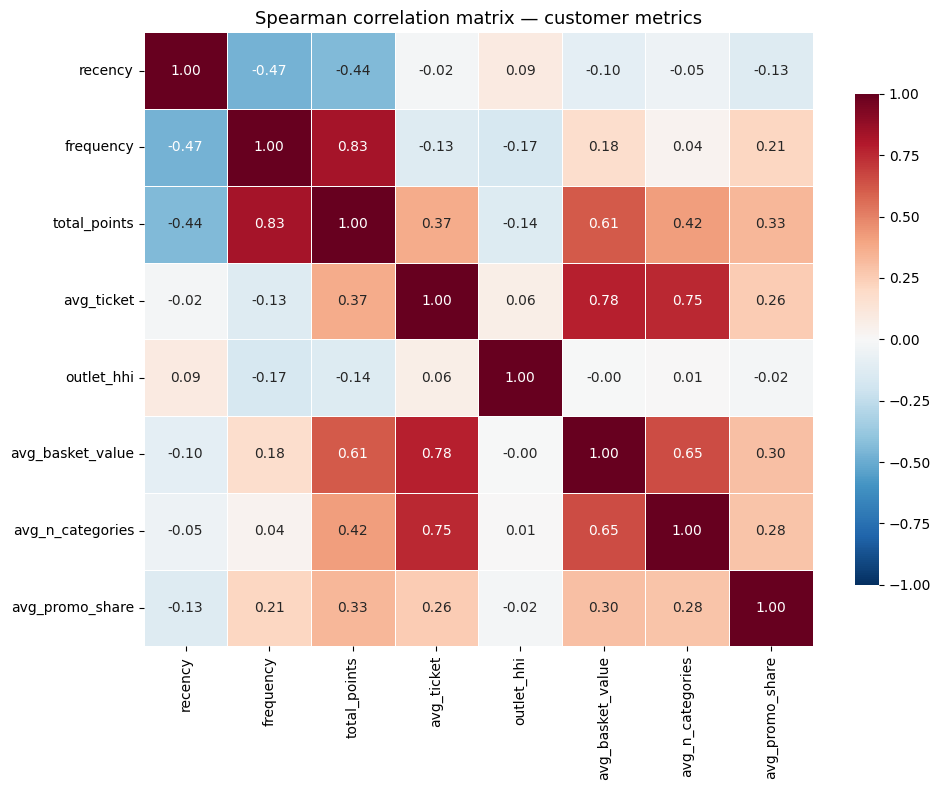


Highly correlated pairs (|Spearman r| > 0.7):
  frequency  ↔  total_points  →  r = 0.83  ⚠ consider dropping one
  avg_ticket  ↔  avg_basket_value  →  r = 0.78  ⚠ consider dropping one
  avg_ticket  ↔  avg_n_categories  →  r = 0.75  ⚠ consider dropping one


In [46]:
import numpy as np
import seaborn as sns
from scipy import stats

metric_cols = [
    'recency', 'frequency', 'total_points', 'avg_ticket',
    'outlet_hhi', 'avg_basket_value', 'avg_n_categories', 'avg_promo_share'
]

# Spearman correlation matrix
corr_matrix = customer_df[metric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Spearman correlation matrix — customer metrics', fontsize=13)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.7)
print("\nHighly correlated pairs (|Spearman r| > 0.7):")
printed = set()
for col_a in metric_cols:
    for col_b in metric_cols:
        if col_a == col_b:
            continue
        pair = frozenset([col_a, col_b])
        if pair in printed:
            continue
        r = corr_matrix.loc[col_a, col_b]
        if abs(r) > 0.7:
            print(f"  {col_a}  ↔  {col_b}  →  r = {r:.2f}  ⚠ consider dropping one")
            printed.add(pair)

### 2.5 Outlier Profiling

We profile extreme customers before deciding whether to exclude them from
the segmentation model.

Three groups are examined:
- **Top 1% spenders** - potential caterers or resellers
- **One-timers** - customers with only one transaction in the window
- **Recently registered** - customers with less than 3 months of history

Each group is assessed on its behavioural profile before a documented
exclusion decision is made.


 Top 1% spenders (n=255)
       recency  frequency  total_points  avg_ticket  outlet_hhi
count   255.00     255.00        255.00      255.00      255.00
mean     17.06      34.51      24566.45      759.29        0.86
std      19.90       8.84       6091.01      335.35        0.20
min       0.00       8.00      19255.00      294.28        0.20
25%       5.00      31.00      20800.00      596.94        0.84
50%      12.00      35.00      22455.00      682.92        0.95
75%      23.00      37.50      26452.50      788.12        1.00
max     170.00      90.00      58130.00     3767.73        1.00


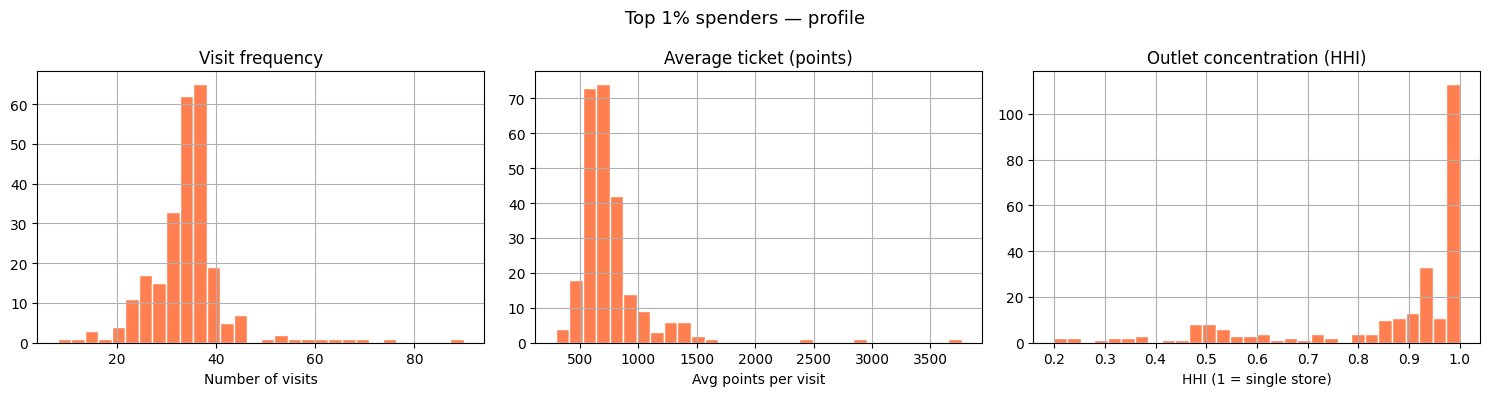


 One-timers (n=484, 1.9% of base) 
       recency  total_points  avg_ticket
count   484.00        484.00      484.00
mean    220.93        501.20      501.20
std     160.09        295.17      295.17
min       2.00          5.00        5.00
25%      92.00        242.50      242.50
50%     187.00        525.00      525.00
75%     317.25        700.00      700.00
max     575.00       1945.00     1945.00

 Recently registered < 3 months (n=58, 0.2% of base)

 Exclusion summary
  Top 1% spenders  :    255
  One-timers       :    484
  Recent (<3 mo)   :     58
  Total excluded   :    784  (3.1% of base)
  Remaining for segmentation: 24,700


In [47]:
snapshot_date = df_retail_sales['DATE'].max()

# Thresholds
p99_spend     = customer_df['total_points'].quantile(0.99)
recent_cutoff = snapshot_date - pd.DateOffset(months=3)

# Group A: top 1% spenders
top_spenders = customer_df[customer_df['total_points'] >= p99_spend].copy()

print(f"\n Top 1% spenders (n={len(top_spenders)})")
print(top_spenders[['recency','frequency','total_points','avg_ticket','outlet_hhi']]\
      .describe(percentiles=[.25,.5,.75]).round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Top 1% spenders — profile", fontsize=13)

top_spenders['frequency'].hist(bins=30, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Visit frequency')
axes[0].set_xlabel('Number of visits')

top_spenders['avg_ticket'].hist(bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average ticket (points)')
axes[1].set_xlabel('Avg points per visit')

top_spenders['outlet_hhi'].hist(bins=30, ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Outlet concentration (HHI)')
axes[2].set_xlabel('HHI (1 = single store)')

plt.tight_layout()
plt.show()

# Group B: one-timers
one_timers = customer_df[customer_df['frequency'] == 1].copy()
print(f"\n One-timers (n={len(one_timers)}, "
      f"{len(one_timers)/len(customer_df):.1%} of base) ")
print(one_timers[['recency','total_points','avg_ticket']]\
      .describe(percentiles=[.25,.5,.75]).round(2))

# Group C: recently registered (< 3 months history)
registry_parsed = df_retail_registry.copy()
registry_parsed['CREATION_DATE'] = pd.to_datetime(registry_parsed['CREATION_DATE'])
recent_registrants = registry_parsed[
    registry_parsed['CREATION_DATE'] >= recent_cutoff
]['CUSTOMER_ID'].tolist()

recent_mask = customer_df['CUSTOMER_ID'].isin(recent_registrants)
print(f"\n Recently registered < 3 months (n={recent_mask.sum()}, "
      f"{recent_mask.mean():.1%} of base)")

# Exclusion summary
exclude_top     = set(top_spenders['CUSTOMER_ID'])
exclude_one     = set(one_timers['CUSTOMER_ID'])
exclude_recent  = set(recent_registrants)
all_exclusions  = exclude_top | exclude_one | exclude_recent

print(f"\n Exclusion summary")
print(f"  Top 1% spenders  : {len(exclude_top):>6,}")
print(f"  One-timers       : {len(exclude_one):>6,}")
print(f"  Recent (<3 mo)   : {len(exclude_recent):>6,}")
print(f"  Total excluded   : {len(all_exclusions):>6,}  "
      f"({len(all_exclusions)/len(customer_df):.1%} of base)")
print(f"  Remaining for segmentation: "
      f"{len(customer_df) - len(all_exclusions):,}")

# Core segmentation dataset
customer_core = customer_df[~customer_df['CUSTOMER_ID'].isin(all_exclusions)].copy()


### 2.6 Segmentation Signal

Before modelling, we test whether the chosen metrics actually discriminate
between different customer types.

We use bivariate scatter plots (raw and log-scale) and cross-tabulations
to check for natural groupings or structural relationships in the data.
This step sets expectations for what the clustering will find and provides
early validation of our metric choices.

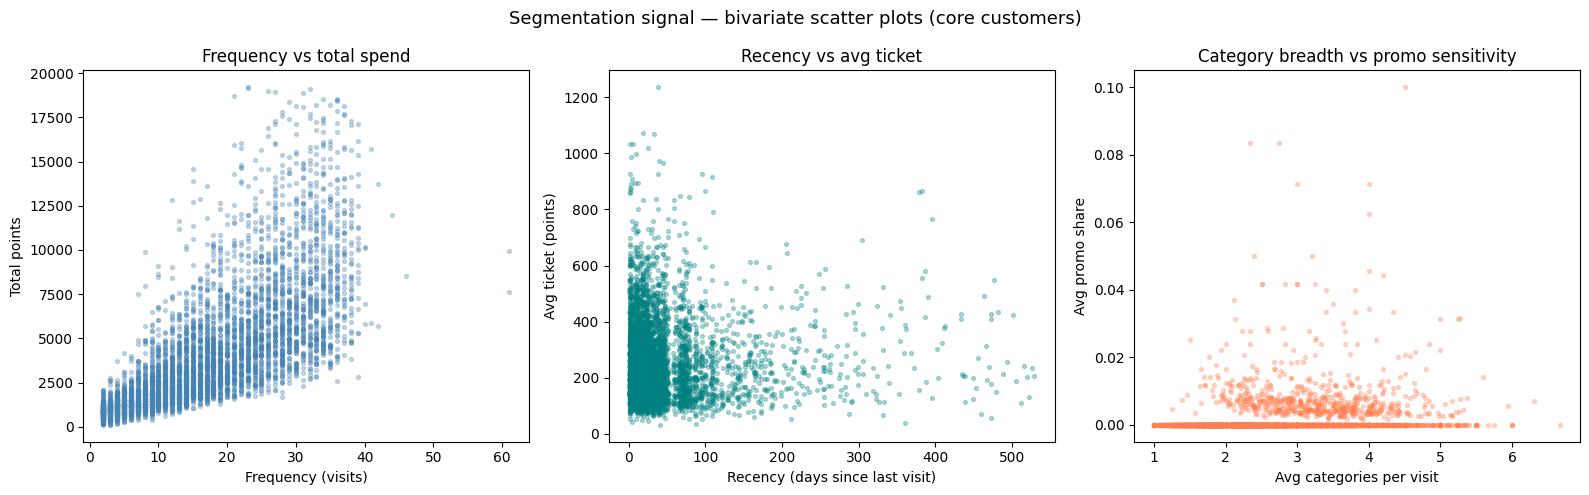

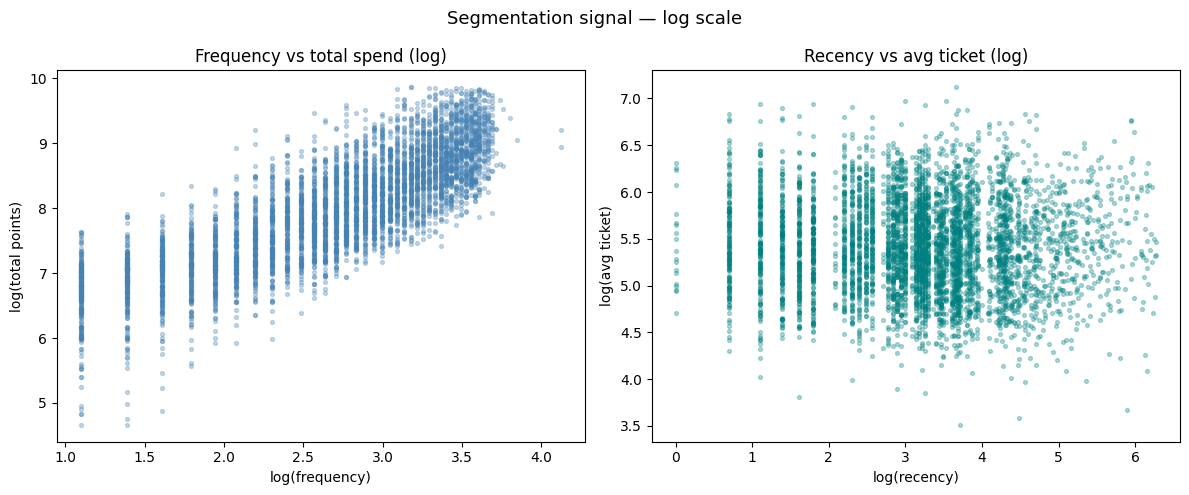


Cross-tab: outlet concentration vs promo sensitivity (row %)
promo_band     Low promo  Medium promo
hhi_band                              
Multi-outlet         1.0           0.0
Mixed                1.0           0.0
Single-outlet        1.0           0.0


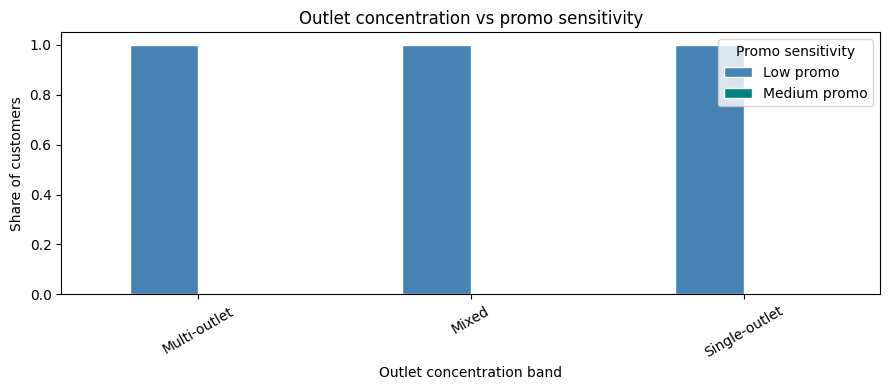

In [48]:
# Bivariate scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Segmentation signal — bivariate scatter plots (core customers)", fontsize=13)

sample = customer_core.sample(min(5000, len(customer_core)), random_state=42)

# Frequency vs total points
axes[0].scatter(sample['frequency'], sample['total_points'],
                alpha=0.3, s=8, color='steelblue')
axes[0].set_xlabel('Frequency (visits)')
axes[0].set_ylabel('Total points')
axes[0].set_title('Frequency vs total spend')

# Recency vs avg ticket
axes[1].scatter(sample['recency'], sample['avg_ticket'],
                alpha=0.3, s=8, color='teal')
axes[1].set_xlabel('Recency (days since last visit)')
axes[1].set_ylabel('Avg ticket (points)')
axes[1].set_title('Recency vs avg ticket')

# Avg categories vs avg promo share
axes[2].scatter(sample['avg_n_categories'], sample['avg_promo_share'],
                alpha=0.3, s=8, color='coral')
axes[2].set_xlabel('Avg categories per visit')
axes[2].set_ylabel('Avg promo share')
axes[2].set_title('Category breadth vs promo sensitivity')

plt.tight_layout()
plt.show()

# Log-scale versions (better visibility on skewed data)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Segmentation signal — log scale", fontsize=13)

axes[0].scatter(np.log1p(sample['frequency']), np.log1p(sample['total_points']),
                alpha=0.3, s=8, color='steelblue')
axes[0].set_xlabel('log(frequency)')
axes[0].set_ylabel('log(total points)')
axes[0].set_title('Frequency vs total spend (log)')

axes[1].scatter(np.log1p(sample['recency']), np.log1p(sample['avg_ticket']),
                alpha=0.3, s=8, color='teal')
axes[1].set_xlabel('log(recency)')
axes[1].set_ylabel('log(avg ticket)')
axes[1].set_title('Recency vs avg ticket (log)')

plt.tight_layout()
plt.show()

# Cross-tab: outlet concentration vs promo sensitivity
customer_core['hhi_band'] = pd.cut(
    customer_core['outlet_hhi'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Multi-outlet', 'Mixed', 'Single-outlet']
)
customer_core['promo_band'] = pd.cut(
    customer_core['avg_promo_share'],
    bins=[-0.01, 0.1, 0.3, 1.01],
    labels=['Low promo', 'Medium promo', 'High promo']
)

crosstab = pd.crosstab(
    customer_core['hhi_band'],
    customer_core['promo_band'],
    normalize='index'
).round(3)

print("\nCross-tab: outlet concentration vs promo sensitivity (row %)")
print(crosstab)

crosstab.plot(kind='bar', figsize=(9, 4), color=['steelblue','teal','coral'],
              edgecolor='white')
plt.title('Outlet concentration vs promo sensitivity')
plt.xlabel('Outlet concentration band')
plt.ylabel('Share of customers')
plt.legend(title='Promo sensitivity')
plt.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 2.7 Checking Data Quality

In [49]:
# Null audit for critical fields
print("\n--- Completeness Checks ---")
print("\nNull values in df_retail_sales:")
print(df_retail_sales[['CUSTOMER_ID', 'DATE', 'TOTAL_POINTS']].isnull().sum())

print("\nNull values in df_retail_sales_detail:")
print(df_retail_sales_detail[['PRODUCT_ID', 'QUANTITY', 'LIST_PRICE']].isnull().sum())

print("\nNull values in df_retail_registry:")
print(df_retail_registry['CREATION_DATE'].isnull().sum())

# Loyalty card attachment rate
total_transactions = len(df_retail_sales)
transactions_with_customer_id = df_retail_sales['CUSTOMER_ID'].count()
attachment_rate = (transactions_with_customer_id / total_transactions) * 100
print(f"\nLoyalty card attachment rate: {attachment_rate:.2f}%")

# Clients in registry with zero transactions
registered_customers = set(df_retail_registry['CUSTOMER_ID'].unique())
purchasing_customers = set(df_retail_sales['CUSTOMER_ID'].unique())
zero_transaction_customers = registered_customers - purchasing_customers
print(f"\nClients in registry with zero transactions: {len(zero_transaction_customers)} customers")
if len(zero_transaction_customers) > 0:
    print(f"  Example zero-transaction customers: {list(zero_transaction_customers)[:5]}")


--- Completeness Checks ---

Null values in df_retail_sales:
CUSTOMER_ID         0
DATE                0
TOTAL_POINTS    21868
dtype: int64

Null values in df_retail_sales_detail:
PRODUCT_ID        0
QUANTITY          0
LIST_PRICE    21704
dtype: int64

Null values in df_retail_registry:
8

Loyalty card attachment rate: 100.00%

Clients in registry with zero transactions: 0 customers


In [50]:
# Convert DATE column in detail_pos to datetime to ensure type consistency for grouping and merging
detail_pos['DATE'] = pd.to_datetime(detail_pos['DATE'])

# Verify total_amount at header level matches sum of line items
# Re-calculate LINE_TOTAL using detail_pos for consistency (already filtered for >0 quantity/price)
detail_pos['CALCULATED_LINE_TOTAL'] = detail_pos['LIST_PRICE'] * detail_pos['QUANTITY']

# Aggregate detail to transaction level
detail_agg_for_sales_match = detail_pos.groupby(['CUSTOMER_ID', 'DATE']).agg(
    total_detail_value=('CALCULATED_LINE_TOTAL', 'sum')
).reset_index()

# Merge with sales header to compare
sales_for_match = df_retail_sales[['CUSTOMER_ID', 'DATE', 'TOTAL_POINTS']].copy()
# df_retail_sales['DATE'] is already datetime from a previous cell, so sales_for_match['DATE'] will be datetime.
# No explicit conversion needed here for sales_for_match['DATE']

merged_sales_check = sales_for_match.merge(
    detail_agg_for_sales_match,
    on=['CUSTOMER_ID', 'DATE'],
    how='left'
)

# Calculate difference (using positive points for consistency)
merged_sales_check['DIFF'] = merged_sales_check['TOTAL_POINTS'] - merged_sales_check['total_detail_value']

# Identify significant mismatches (e.g., >1% of total_points or a fixed small amount)
mismatch_threshold = 0.01  # 1%
mismatched_transactions = merged_sales_check[
    (merged_sales_check['DIFF'].abs() / merged_sales_check['TOTAL_POINTS'].abs()) > mismatch_threshold
]

print("\n--- Consistency & Format Checks ---")
print(f"Transactions with significant total_points mismatch (> {mismatch_threshold*100}%): {len(mismatched_transactions)}")
if not mismatched_transactions.empty:
    print("  Example mismatched transactions:")
    display(mismatched_transactions.head())

# Check for negative amounts (explicitly, though already handled in previous cells for analysis)
print(f"\nNegative TOTAL_POINTS in df_retail_sales: {(df_retail_sales['TOTAL_POINTS'] < 0).sum()}")
print(f"Negative QUANTITY in df_retail_sales_detail: {(df_retail_sales_detail['QUANTITY'] < 0).sum()}")
print(f"Negative LIST_PRICE in df_retail_sales_detail: {(df_retail_sales_detail['LIST_PRICE'] < 0).sum()}")

# Duplicate detection (exact duplicates on CUSTOMER_ID, DATE, TOTAL_POINTS within same minute)
# Need TIME column for this, which is in df_retail_sales
df_retail_sales['DATETIME'] = pd.to_datetime(df_retail_sales['DATE'].astype(str) + ' ' + df_retail_sales['TIME'].astype(str))

duplicate_transactions = df_retail_sales[df_retail_sales.duplicated(subset=['CUSTOMER_ID', 'DATETIME', 'TOTAL_POINTS'], keep=False)]
print(f"\nDuplicate transactions (CUSTOMER_ID, DATETIME, TOTAL_POINTS): {len(duplicate_transactions)}")
if not duplicate_transactions.empty:
    print("  Example duplicate transactions:")
    display(duplicate_transactions.sort_values(by=['CUSTOMER_ID', 'DATETIME']).head())


--- Consistency & Format Checks ---
Transactions with significant total_points mismatch (> 1.0%): 467638
  Example mismatched transactions:


,CUSTOMER_ID,DATE,TOTAL_POINTS,total_detail_value,DIFF
0,AA00312188,2019-02-14,290.0,55.30,234.70
1,AA00312188,2019-02-28,155.0,41.05,113.95
2,AA00312188,2019-03-14,295.0,50.65,244.35
3,AA00312188,2018-09-27,115.0,14.20,100.80
4,AA00312188,2019-04-25,290.0,64.60,225.40



Negative TOTAL_POINTS in df_retail_sales: 24099
Negative QUANTITY in df_retail_sales_detail: 343
Negative LIST_PRICE in df_retail_sales_detail: 20385

Duplicate transactions (CUSTOMER_ID, DATETIME, TOTAL_POINTS): 0


In [51]:
# Check for orphan CUSTOMER_ID in df_retail_sales (not in df_retail_registry)
sales_customers = set(df_retail_sales['CUSTOMER_ID'].unique())
registry_customers = set(df_retail_registry['CUSTOMER_ID'].unique())
orphan_sales_customers = sales_customers - registry_customers
print("\n--- Linkage Integrity Checks ---")
print(f"Orphan CUSTOMER_IDs in sales (not in registry): {len(orphan_sales_customers)}")
if len(orphan_sales_customers) > 0:
    print(f"  Example orphan CUSTOMER_IDs: {list(orphan_sales_customers)[:5]}")

# Check for orphan PRODUCT_ID in df_retail_sales_detail (not in df_retail_products)
detail_products = set(df_retail_sales_detail['PRODUCT_ID'].unique())
master_products = set(df_retail_products['PRODUCT_ID'].unique())
orphan_detail_products = detail_products - master_products
print(f"\nOrphan PRODUCT_IDs in sales detail (not in product master): {len(orphan_detail_products)}")
if len(orphan_detail_products) > 0:
    print(f"  Example orphan PRODUCT_IDs: {list(orphan_detail_products)[:5]}")

# Cardinality check: customers with 1000+ transactions per year
# Assuming a ~2 year window, so 2000+ transactions total is suspicious
high_frequency_customers = customer_df[customer_df['frequency'] > 1000]
print(f"\nCustomers with > 1000 transactions: {len(high_frequency_customers)}")
if not high_frequency_customers.empty:
    print("  Example high-frequency customers:")
    display(high_frequency_customers.head())

# Cardinality check: receipts with 200+ line items
high_line_item_baskets = basket[basket['total_items_count'] > 200]
print(f"\nReceipts with > 200 line items: {len(high_line_item_baskets)}")
if not high_line_item_baskets.empty:
    print("  Example high line-item receipts:")
    display(high_line_item_baskets.head())


--- Linkage Integrity Checks ---
Orphan CUSTOMER_IDs in sales (not in registry): 1
  Example orphan CUSTOMER_IDs: ['WO01027977']

Orphan PRODUCT_IDs in sales detail (not in product master): 2
  Example orphan PRODUCT_IDs: [np.int64(232395), np.int64(-12)]

Customers with > 1000 transactions: 0

Receipts with > 200 line items: 0


In [52]:
print("\n--- Temporal Validity Checks ---")
print("Previous plots in 'Temporal Patterns' section already highlighted a significant drop in transactions around early 2020 (likely COVID-19 lockdown).")
print("This confirms the need for careful consideration of the observation window. The current analysis uses a snapshot date of the latest transaction to calculate recency and frequency, and the 'customer_core' dataset excludes 'one-timers' and 'recently registered' customers, which helps in focusing on more stable customer behavior.")
print("Future steps might involve explicitly defining an observation window (e.g., trailing 12 months) for certain segmentation models to mitigate the impact of historical anomalies.")


--- Temporal Validity Checks ---
Previous plots in 'Temporal Patterns' section already highlighted a significant drop in transactions around early 2020 (likely COVID-19 lockdown).
This confirms the need for careful consideration of the observation window. The current analysis uses a snapshot date of the latest transaction to calculate recency and frequency, and the 'customer_core' dataset excludes 'one-timers' and 'recently registered' customers, which helps in focusing on more stable customer behavior.
Future steps might involve explicitly defining an observation window (e.g., trailing 12 months) for certain segmentation models to mitigate the impact of historical anomalies.


In [53]:
# Identify statistical outliers on spend (top 0.1%)
# We already identified top 1% spenders. Let's get top 0.1%
p999_spend = customer_df['total_points'].quantile(0.999)
top_0_1_percent_spenders = customer_df[customer_df['total_points'] >= p999_spend].copy()
print("\n--- Behavioural Plausibility Checks ---")
print(f"Customers in top 0.1% spend (n={len(top_0_1_percent_spenders)}):")
if not top_0_1_percent_spenders.empty:
    display(top_0_1_percent_spenders[['CUSTOMER_ID', 'total_points', 'frequency']].head())

# Check for implausibly large quantities on single items (e.g. 500 units of fresh produce)
implausibly_large_quantities = df_retail_sales_detail[df_retail_sales_detail['QUANTITY'] > 500]
print(f"\nSales detail lines with implausibly large quantities (>500 units): {len(implausibly_large_quantities)}")
if not implausibly_large_quantities.empty:
    print("  Example implausibly large quantity items:")
    display(implausibly_large_quantities.head())

print("\nIdentifying test accounts and staff cards usually requires specific prefixes, registration data, or external lists. This dataset does not contain explicit information for these checks, but they should be considered if such data becomes available.")


--- Behavioural Plausibility Checks ---
Customers in top 0.1% spend (n=26):


,CUSTOMER_ID,total_points,frequency
466,AL00985338,46950.0,33
584,AO00403523,35285.0,34
1789,BT01050226,31475.0,33
5312,FG00405885,38965.0,36
7075,HB00395136,36700.0,33



Sales detail lines with implausibly large quantities (>500 units): 3
  Example implausibly large quantity items:


,CUSTOMER_ID,DATE,PRODUCT_ID,QUANTITY,LIST_PRICE,SPECIAL
1641813,QQ01052928,2018-10-27,4095,600.0,30.0,NaN
1645109,QQ01052928,2018-09-15,4095,800.0,40.0,NaN
1648949,QQ01052928,2019-01-05,4095,1000.0,50.0,NaN



Identifying test accounts and staff cards usually requires specific prefixes, registration data, or external lists. This dataset does not contain explicit information for these checks, but they should be considered if such data becomes available.


## 3. Data Cleaning

Based on the quality checks and outlier profiling, we apply the following
documented exclusions before modelling:

| Decision | Rationale |
|---|---|
| Exclude customer `WO01027977` | Orphan ID - not in registry |
| Exclude product IDs `232395` and `-12` | Not in product master |
| Exclude lines with quantity > 500 | Implausible, likely errors |
| Filter to positive TOTAL_POINTS and LIST_PRICE | Negatives are returns |
| Trim to trailing 12 months | Avoids COVID-era distortion |

After cleaning: **299,861 transaction headers** and **1,281,003 receipt lines**.


In [54]:
print("\n--- Applying Data Cleaning Decisions ---")

# Reinitialize dataframes to ensure starting with full datasets
# Use the correct keys for the 'dataframes' dictionary as it was redefined in cell 559e0b99-f7a9-452e-b4f1-0fb92f18a212
df_retail_sales = dataframes['df_retail_sales'].copy()
df_retail_sales_detail = dataframes['df_retail_sales_detail'].copy()

# 9. Convert 'DATE' columns to datetime first to ensure proper filtering
df_retail_sales['DATE'] = pd.to_datetime(df_retail_sales['DATE'])
df_retail_sales_detail['DATE'] = pd.to_datetime(df_retail_sales_detail['DATE'])
print("Converted 'DATE' columns to datetime.")

# 1. Define orphan customer ID
orphan_customer_id = 'WO01027977'

# 2. Filter df_retail_sales to exclude orphan customer ID
df_retail_sales = df_retail_sales[df_retail_sales['CUSTOMER_ID'] != orphan_customer_id]
print(f"df_retail_sales after excluding orphan customer: {df_retail_sales.shape[0]} rows")

# 3. Filter df_retail_sales_detail to exclude orphan customer ID
df_retail_sales_detail = df_retail_sales_detail[df_retail_sales_detail['CUSTOMER_ID'] != orphan_customer_id]
print(f"df_retail_sales_detail after excluding orphan customer: {df_retail_sales_detail.shape[0]} rows")

# 4. Define product IDs to exclude
orphan_product_ids = [232395, -12]

# 5. Filter df_retail_sales_detail to exclude orphan product IDs
df_retail_sales_detail = df_retail_sales_detail[~df_retail_sales_detail['PRODUCT_ID'].isin(orphan_product_ids)]
print(f"df_retail_sales_detail after excluding orphan product IDs: {df_retail_sales_detail.shape[0]} rows")

# 6. Filter df_retail_sales_detail to exclude records where QUANTITY > 500
df_retail_sales_detail = df_retail_sales_detail[df_retail_sales_detail['QUANTITY'] <= 500]
print(f"df_retail_sales_detail after excluding quantity > 500: {df_retail_sales_detail.shape[0]} rows")

# 7. Filter df_retail_sales to include only records where TOTAL_POINTS > 0 and not null
df_retail_sales = df_retail_sales[df_retail_sales['TOTAL_POINTS'].notna()]
df_retail_sales = df_retail_sales[df_retail_sales['TOTAL_POINTS'] > 0]
print(f"df_retail_sales after excluding null/negative TOTAL_POINTS: {df_retail_sales.shape[0]} rows")

# 8. Filter df_retail_sales_detail to include only records where LIST_PRICE > 0 and not null
df_retail_sales_detail = df_retail_sales_detail[df_retail_sales_detail['LIST_PRICE'].notna()]
df_retail_sales_detail = df_retail_sales_detail[df_retail_sales_detail['LIST_PRICE'] > 0]
print(f"df_retail_sales_detail after excluding null/negative LIST_PRICE: {df_retail_sales_detail.shape[0]} rows")

# Recalculate snapshot_date based on the current (cleaned so far) df_retail_sales
# Only proceed if df_retail_sales is not empty
if not df_retail_sales.empty:
    snapshot_date = df_retail_sales['DATE'].max()
    # Define the observation window start date (last 12 months from snapshot_date)
    observation_start_date = snapshot_date - pd.DateOffset(months=12)
    print(f"Observation window start date: {observation_start_date.strftime('%Y-%m-%d')}")

    # 10. Filter df_retail_sales to include only transactions on or after observation_start_date
    df_retail_sales = df_retail_sales[df_retail_sales['DATE'] >= observation_start_date]
    print(f"df_retail_sales after trimming observation window: {df_retail_sales.shape[0]} rows")

    # 11. Filter df_retail_sales_detail to include only transactions on or after observation_start_date
    df_retail_sales_detail = df_retail_sales_detail[df_retail_sales_detail['DATE'] >= observation_start_date]
    print(f"df_retail_sales_detail after trimming observation window: {df_retail_sales_detail.shape[0]} rows")
else:
    print("df_retail_sales is empty after initial filtering, cannot apply temporal window.")

print("\n--- Cleaning decisions applied successfully. ---")
print(f"Final shape of df_retail_sales: {df_retail_sales.shape}")
print(f"Final shape of df_retail_sales_detail: {df_retail_sales_detail.shape}")


--- Applying Data Cleaning Decisions ---
Converted 'DATE' columns to datetime.
df_retail_sales after excluding orphan customer: 489965 rows
df_retail_sales_detail after excluding orphan customer: 2047065 rows
df_retail_sales_detail after excluding orphan product IDs: 2043785 rows
df_retail_sales_detail after excluding quantity > 500: 2043782 rows
df_retail_sales after excluding null/negative TOTAL_POINTS: 442671 rows
df_retail_sales_detail after excluding null/negative LIST_PRICE: 1946496 rows
Observation window start date: 2019-01-26
df_retail_sales after trimming observation window: 299861 rows
df_retail_sales_detail after trimming observation window: 1281003 rows

--- Cleaning decisions applied successfully. ---
Final shape of df_retail_sales: (299861, 10)
Final shape of df_retail_sales_detail: (1281003, 6)


Recalculating customer-level metrics using the cleaned data. Doing this by updating the snapshot date, enriching sales detail data with product categories, aggregating transaction-level data into a basket DataFrame, and then aggregating customer-level RFM and basket metrics. Finally, these customer-level metrics will be merged to form the new `customer_df`.



## 4. Feature Engineering

We prepare the customer-level metric table for clustering by:

1. **Log-transforming** skewed metrics - recency, frequency, total points,
and avg ticket are all right-skewed; log transformation makes them more
suitable for k-means which assumes roughly spherical clusters
2. **Dropping redundant metrics** - based on the correlation analysis,
highly correlated features are removed to avoid double-weighting
3. **Scaling** - all features are standardised using StandardScaler so
no single metric dominates the clustering due to its unit of measurement

Final feature set: `recency`, `outlet_hhi`, `avg_promo_share`,
`total_points_log`, `frequency_log`, `avg_ticket_log`




In [66]:
print("--- Re-engineering Customer-Level Features ---")

# 1. Recalculate the snapshot_date
snapshot_date = df_retail_sales['DATE'].max()
print(f"Recalculated snapshot_date: {snapshot_date}")

# 2. Merge cleaned df_retail_sales_detail with df_retail_products
detail_enriched = df_retail_sales_detail.merge(
    df_retail_products[['PRODUCT_ID', 'CATEGORY_ID']],
    on='PRODUCT_ID', how='left'
)
print(f"Shape of detail_enriched: {detail_enriched.shape}")

# 3. Create a basket DataFrame
basket = detail_enriched[detail_enriched['QUANTITY'] > 0].groupby(
    ['CUSTOMER_ID', 'DATE']
).agg(
    basket_value      = ('LIST_PRICE', lambda x: (x * detail_enriched.loc[x.index, 'QUANTITY']).sum()),
    n_items           = ('QUANTITY', 'sum'),
    n_categories      = ('CATEGORY_ID', 'nunique'),
    promo_items       = ('SPECIAL', lambda x: x.notna().sum()),
    total_items_count = ('QUANTITY', 'count')
).reset_index()
basket['promo_share'] = basket['promo_items'] / basket['total_items_count']
print(f"Shape of basket: {basket.shape}")

# Helper function for Herfindahl index (defined in previous cell `af0a2bb8-047e-497e-abd5-bb37da2030db`)
def herfindahl(series):
    counts = series.value_counts(normalize=True)
    return (counts ** 2).sum()

# 4. Calculate rfm metrics
rfm = df_retail_sales[df_retail_sales['TOTAL_POINTS'] > 0].groupby('CUSTOMER_ID').agg(
    recency      = ('DATE', lambda x: (snapshot_date - x.max()).days),
    frequency    = ('DATE', 'count'),
    total_points = ('TOTAL_POINTS', 'sum'),
    avg_ticket   = ('TOTAL_POINTS', 'mean'),
    outlet_hhi   = ('OUTLET_ID', herfindahl)
).reset_index()
print(f"Shape of rfm: {rfm.shape}")

# 5. Calculate basket_agg metrics
basket_agg = basket.groupby('CUSTOMER_ID').agg(
    avg_basket_value  = ('basket_value', 'mean'),
    avg_n_categories  = ('n_categories', 'mean'),
    avg_promo_share   = ('promo_share', 'mean')
).reset_index()
print(f"Shape of basket_agg: {basket_agg.shape}")

# 6. Merge rfm and basket_agg into customer_df
customer_df = rfm.merge(basket_agg, on='CUSTOMER_ID', how='left')

# 7. Print the shape and first 5 rows of customer_df
print(f"\nFinal customer_df shape: {customer_df.shape}")
print("\nCustomer table preview:")
print(customer_df.head())

--- Re-engineering Customer-Level Features ---
Recalculated snapshot_date: 2020-01-26 00:00:00
Shape of detail_enriched: (1281003, 7)
Shape of basket: (325295, 8)
Shape of rfm: (25193, 6)
Shape of basket_agg: (25497, 4)

Final customer_df shape: (25193, 9)

Customer table preview:
  CUSTOMER_ID  recency  frequency  total_points  avg_ticket  outlet_hhi  \
0  AA00312188       24         14        3890.0  277.857143    0.632653   
1  AA00312390       71         13        1665.0  128.076923    1.000000   
2  AA00325975        1         21        6645.0  316.428571    0.909297   
3  AA00336843       14         15        2115.0  141.000000    0.493333   
4  AA00339761       23          8        1535.0  191.875000    1.000000   

   avg_basket_value  avg_n_categories  avg_promo_share  
0         48.782143          3.428571              0.0  
1         20.721053          1.631579              0.0  
2         40.345652          3.434783              0.0  
3         23.510000          1.866667  

### 4.1 Log-transform skewed metrics



In [67]:
print("--- Applying Log-Transformation to Skewed Metrics ---")

# Create new columns for log-transformed metrics
customer_df['total_points_log'] = np.log1p(customer_df['total_points'])
customer_df['frequency_log']    = np.log1p(customer_df['frequency'])
customer_df['avg_ticket_log']   = np.log1p(customer_df['avg_ticket'])

print("Log transformations applied to 'total_points', 'frequency', and 'avg_ticket'.")

# Display the head of the customer_df to verify the new columns
print("\nCustomer table preview with log-transformed metrics:")
print(customer_df.head())

--- Applying Log-Transformation to Skewed Metrics ---
Log transformations applied to 'total_points', 'frequency', and 'avg_ticket'.

Customer table preview with log-transformed metrics:
  CUSTOMER_ID  recency  frequency  total_points  avg_ticket  outlet_hhi  \
0  AA00312188       24         14        3890.0  277.857143    0.632653   
1  AA00312390       71         13        1665.0  128.076923    1.000000   
2  AA00325975        1         21        6645.0  316.428571    0.909297   
3  AA00336843       14         15        2115.0  141.000000    0.493333   
4  AA00339761       23          8        1535.0  191.875000    1.000000   

   avg_basket_value  avg_n_categories  avg_promo_share  total_points_log  \
0         48.782143          3.428571              0.0          8.266421   
1         20.721053          1.631579              0.0          7.418181   
2         40.345652          3.434783              0.0          8.801770   
3         23.510000          1.866667              0.0     

### 4.2 Visualizing The Effects Of The Log Transformation




--- Visualizing Log-Transformed Metrics ---


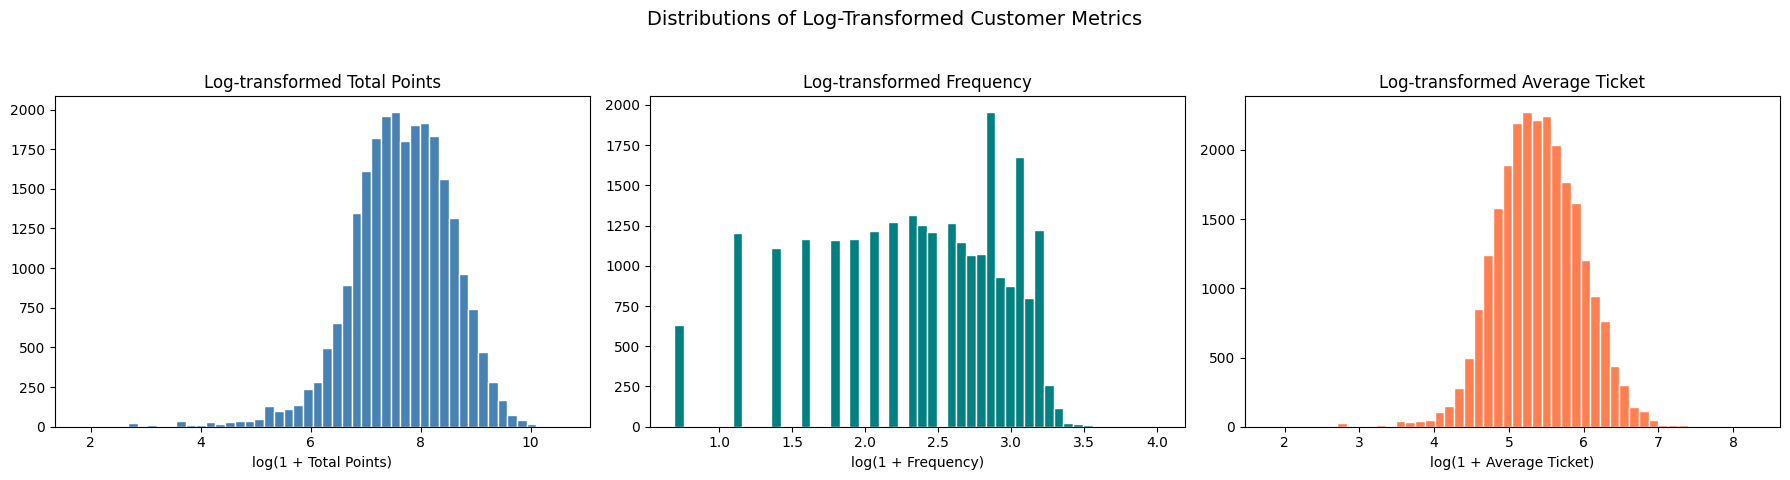

Visualizations complete. The log transformations appear to have reduced the skewness of the distributions.


In [68]:
import matplotlib.pyplot as plt

print("--- Visualizing Log-Transformed Metrics ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distributions of Log-Transformed Customer Metrics", fontsize=14)

# Plot total_points_log
axes[0].hist(customer_df['total_points_log'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Log-transformed Total Points')
axes[0].set_xlabel('log(1 + Total Points)')

# Plot frequency_log
axes[1].hist(customer_df['frequency_log'].dropna(), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Log-transformed Frequency')
axes[1].set_xlabel('log(1 + Frequency)')

# Plot avg_ticket_log
axes[2].hist(customer_df['avg_ticket_log'].dropna(), bins=50, color='coral', edgecolor='white')
axes[2].set_title('Log-transformed Average Ticket')
axes[2].set_xlabel('log(1 + Average Ticket)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Visualizations complete. The log transformations appear to have reduced the skewness of the distributions.")

### 4.3 Drop Redundant Metrics



In [69]:
print(" Dropping Redundant Metrics ")

# Identify columns to drop based on correlation analysis and instructions
columns_to_drop = [
    'frequency',        # Redundant with frequency_log, high correlation with total_points
    'total_points',     # Redundant with total_points_log, high correlation with frequency
    'avg_ticket',       # Redundant with avg_ticket_log, high correlation with avg_basket_value and avg_n_categories
    'avg_basket_value', # High correlation with avg_ticket
    'avg_n_categories'  # High correlation with avg_ticket
]

# Filter columns_to_drop to only include those that actually exist in customer_df
existing_columns_to_drop = [col for col in columns_to_drop if col in customer_df.columns]

# Drop the identified columns from customer_df
customer_df = customer_df.drop(columns=existing_columns_to_drop, errors='ignore')

print(f"Dropped columns: {existing_columns_to_drop}")
print(f"New shape of customer_df: {customer_df.shape}")

# Display the first few rows of the modified customer_df
print("\nCustomer table preview after dropping redundant metrics:")
print(customer_df.head())

 Dropping Redundant Metrics 
Dropped columns: ['frequency', 'total_points', 'avg_ticket', 'avg_basket_value', 'avg_n_categories']
New shape of customer_df: (25193, 7)

Customer table preview after dropping redundant metrics:
  CUSTOMER_ID  recency  outlet_hhi  avg_promo_share  total_points_log  \
0  AA00312188       24    0.632653              0.0          8.266421   
1  AA00312390       71    1.000000              0.0          7.418181   
2  AA00325975        1    0.909297              0.0          8.801770   
3  AA00336843       14    0.493333              0.0          7.657283   
4  AA00339761       23    1.000000              0.0          7.336937   

   frequency_log  avg_ticket_log  
0       2.708050        5.630700  
1       2.639057        4.860409  
2       3.091042        5.760253  
3       2.772589        4.955827  
4       2.197225        5.262042  


### 4.4 Scale Features



In [77]:
from sklearn.preprocessing import StandardScaler

print(" Scaling Numerical Features ")

# Identify numerical features to scale
# Exclude 'CUSTOMER_ID' as it's an identifier
numerical_features = [
    'recency',
    'outlet_hhi',
    'avg_promo_share',
    'total_points_log',
    'frequency_log',
    'avg_ticket_log'
]

# Create a DataFrame with only the numerical features
customer_features = customer_df[numerical_features].copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
customer_scaled_array = scaler.fit_transform(customer_features)

# Convert the scaled array back to a DataFrame
customer_scaled = pd.DataFrame(customer_scaled_array, columns=numerical_features)

print("Numerical features scaled successfully.")

# Display the head of the customer_scaled DataFrame
print("\nCustomer_scaled DataFrame preview:")
print(customer_scaled.head())

 Scaling Numerical Features 
Numerical features scaled successfully.

Customer_scaled DataFrame preview:
    recency  outlet_hhi  avg_promo_share  total_points_log  frequency_log  \
0 -0.338208   -1.254407        -0.284143          0.683652       0.504635   
1  0.507003    0.636548        -0.284143         -0.247940       0.396846   
2 -0.751823    0.169646        -0.284143          1.271606       1.102995   
3 -0.518041   -1.971569        -0.284143          0.014657       0.605466   
4 -0.356192    0.636548        -0.284143         -0.337167      -0.293442   

   avg_ticket_log  
0        0.417857  
1       -0.944259  
2        0.646948  
3       -0.775529  
4       -0.234045  


## 5. Segmentation Modelling

We apply k-means clustering to the scaled customer feature table.

The optimal number of clusters is determined using two methods:
- **Elbow method** - plots within-cluster sum of squares (WCSS) against k;
  we look for the point where adding more clusters yields diminishing returns
- **Silhouette score** - measures how well each customer fits its own cluster
  vs neighbouring clusters; higher is better (range: -1 to 1)

**Result: k = 5** selected as the optimal number of segments.

### 5.1 K-Means Clustering


--- Determining Optimal Number of Clusters ---


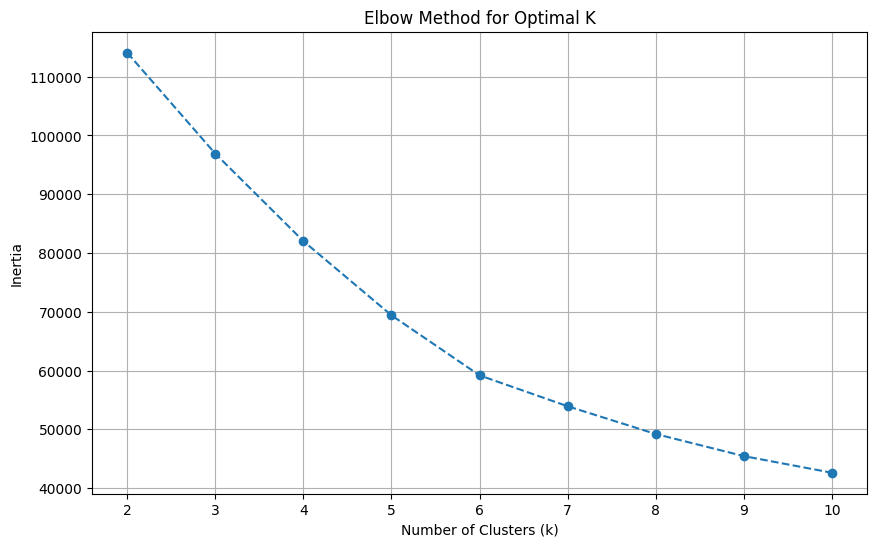

Elbow Method plot generated.


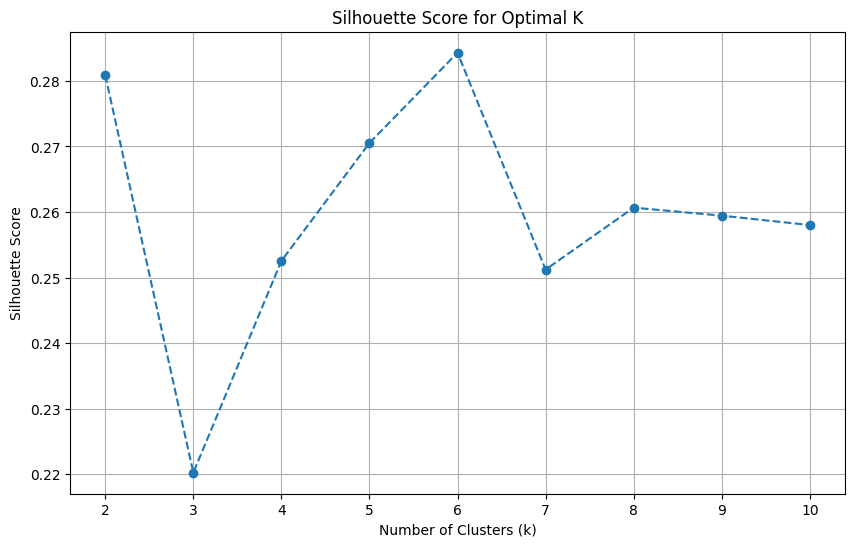

Silhouette Score plot generated.


In [72]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("--- Determining Optimal Number of Clusters ---")

# --- Elbow Method ---

inertia = []
# Loop through a range of possible cluster numbers (e.g., from 2 to 10).
# It is a common practice to start from 2 clusters for silhouette_score
# as it requires at least 2 clusters.
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is explicitly set to avoid future warnings
    kmeans.fit(customer_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

print("Elbow Method plot generated.")

# --- Silhouette Score Method ---

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customer_scaled)
    labels = kmeans.predict(customer_scaled)
    score = silhouette_score(customer_scaled, labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score results
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

print("Silhouette Score plot generated.")

### 5.2 Using Elbow Method and Silhouette Score plots to select  an optimal number of clusters (k).



In [73]:
print("--- Applying K-Means Clustering ---")

# Select optimal 'k' based on Elbow Method and Silhouette Score
# From the plots, k=5 appears to be a reasonable choice.
optimal_k = 5
print(f"Selected optimal number of clusters (k): {optimal_k}")

# Instantiate KMeans model with the chosen optimal_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit the K-Means model to the customer_scaled DataFrame
kmeans.fit(customer_scaled)

# Add the cluster labels as a new column named 'cluster_label' to the original customer_df DataFrame
customer_df['cluster_label'] = kmeans.labels_

# Calculate revenue by cluster using the original total_points AFTER it's dropped from customer_df
# To do this, we need to temporarily merge the original total_points from the rfm DataFrame
# as total_points was already dropped from customer_df by an earlier cell.
temp_customer_df = customer_df.merge(rfm[['CUSTOMER_ID', 'total_points']], on='CUSTOMER_ID', how='left')
revenue_by_cluster = temp_customer_df.groupby('cluster_label')['total_points'].sum()

print("K-Means clustering applied and cluster labels added to customer_df.")

# Display the head of the customer_df to verify the new column
print("\nCustomer table preview with cluster labels:")
print(customer_df.head())

--- Applying K-Means Clustering ---
Selected optimal number of clusters (k): 5
K-Means clustering applied and cluster labels added to customer_df.

Customer table preview with cluster labels:
  CUSTOMER_ID  recency  outlet_hhi  avg_promo_share  total_points_log  \
0  AA00312188       24    0.632653              0.0          8.266421   
1  AA00312390       71    1.000000              0.0          7.418181   
2  AA00325975        1    0.909297              0.0          8.801770   
3  AA00336843       14    0.493333              0.0          7.657283   
4  AA00339761       23    1.000000              0.0          7.336937   

   frequency_log  avg_ticket_log  cluster_label  
0       2.708050        5.630700              2  
1       2.639057        4.860409              0  
2       3.091042        5.760253              3  
3       2.772589        4.955827              2  
4       2.197225        5.262042              0  


## 6. Segment Profiling

With 5 clusters identified, we now profile each one to understand its
characteristics and assign a business name.

We examine:
- **6.1 Segment size** - customer count and % share of base
- **6.2 Mean profile** - average metric values per cluster
- **6.3 Radar chart** - visual personality of each segment
- **6.4 Heatmap** - normalised profile with actual values annotated
- **6.5 Box plots** - internal distribution within each cluster
- **6.6 Revenue share** - customer % vs spend % per segment

── Segment sizes ──
 cluster_label  n_customers  pct
             0         9075 36.0
             1         2156  8.6
             2         4229 16.8
             3         8898 35.3
             4          835  3.3

── Segment mean profiles (log-transformed scale) ──
cluster_label         0       1      2      3      4
recency           37.62  186.95  32.60  19.31  29.04
outlet_hhi         0.97    0.94   0.51   0.94   0.89
avg_promo_share    0.00    0.00   0.00   0.00   0.03
total_points_log   7.18    6.10   7.66   8.46   7.87
frequency_log      2.17    1.25   2.41   2.88   2.26
avg_ticket_log     5.16    5.24   5.37   5.64   5.74


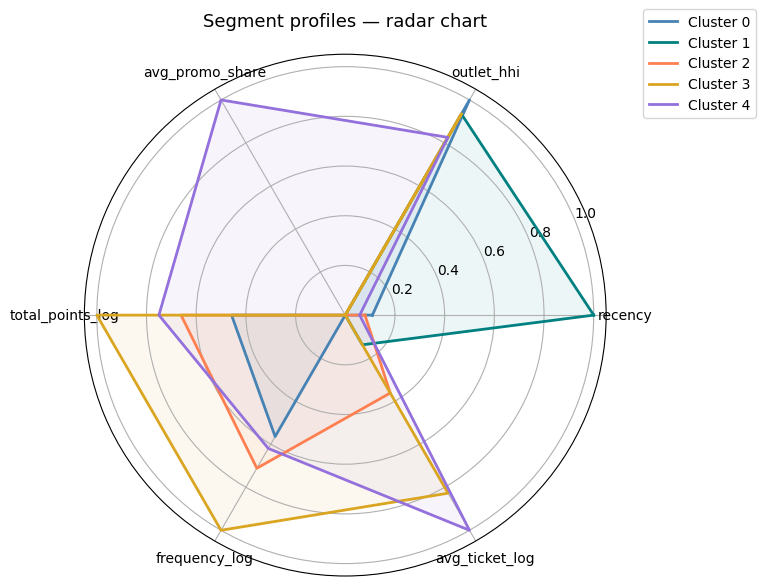

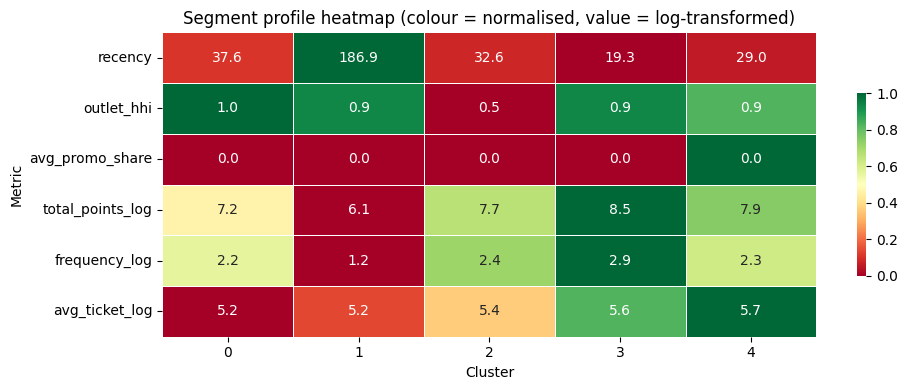

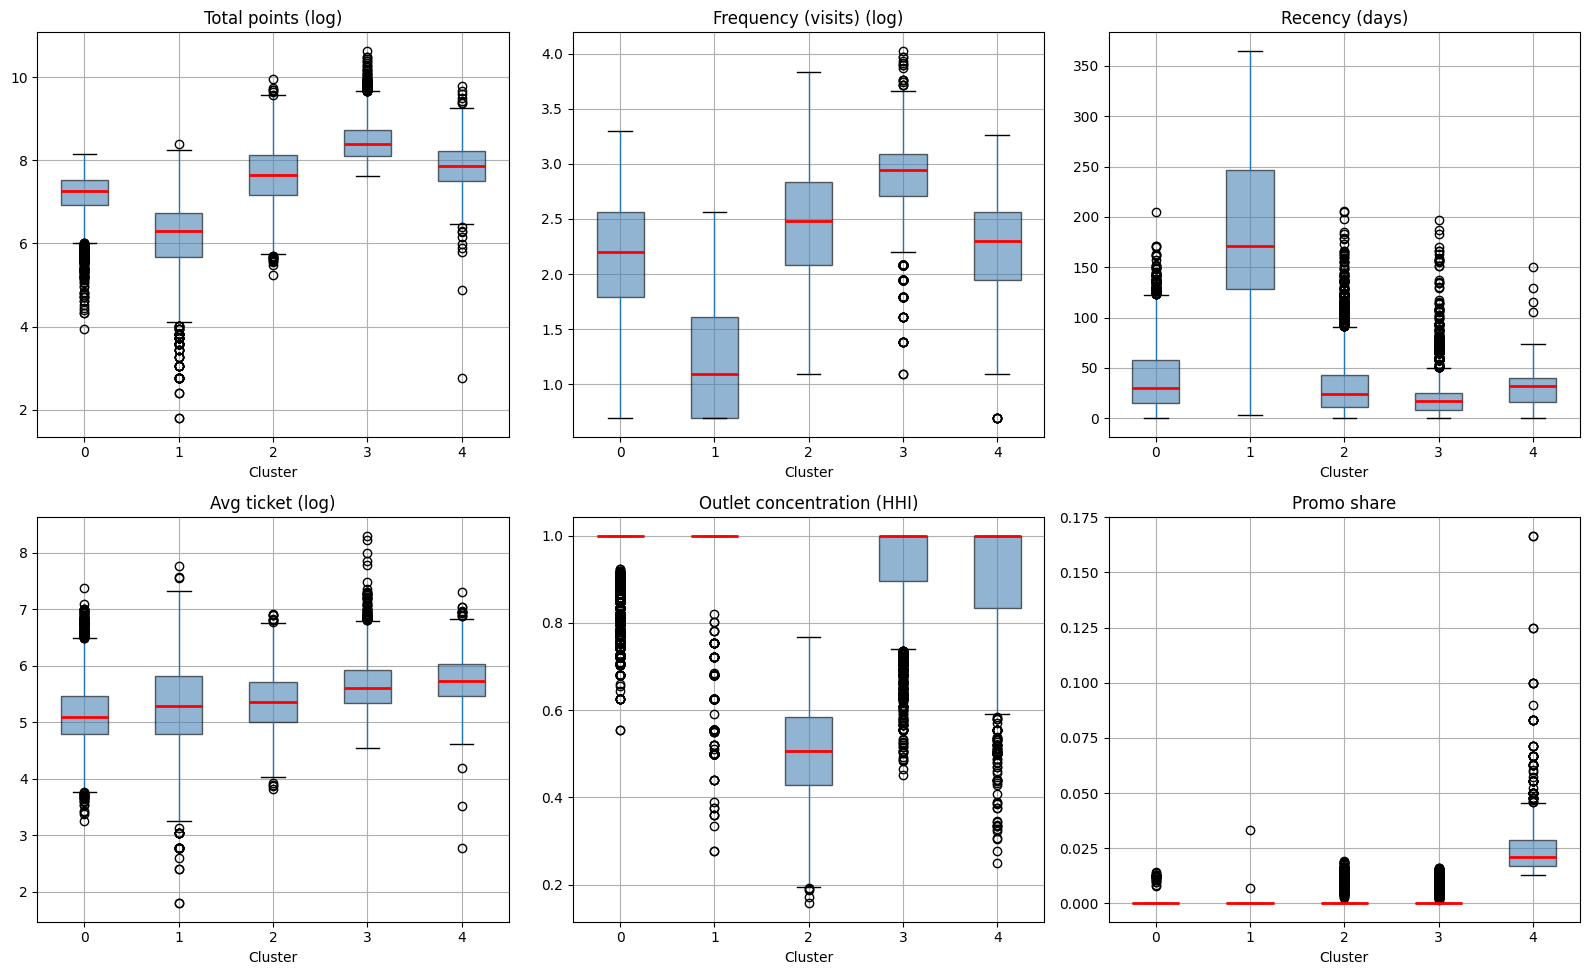

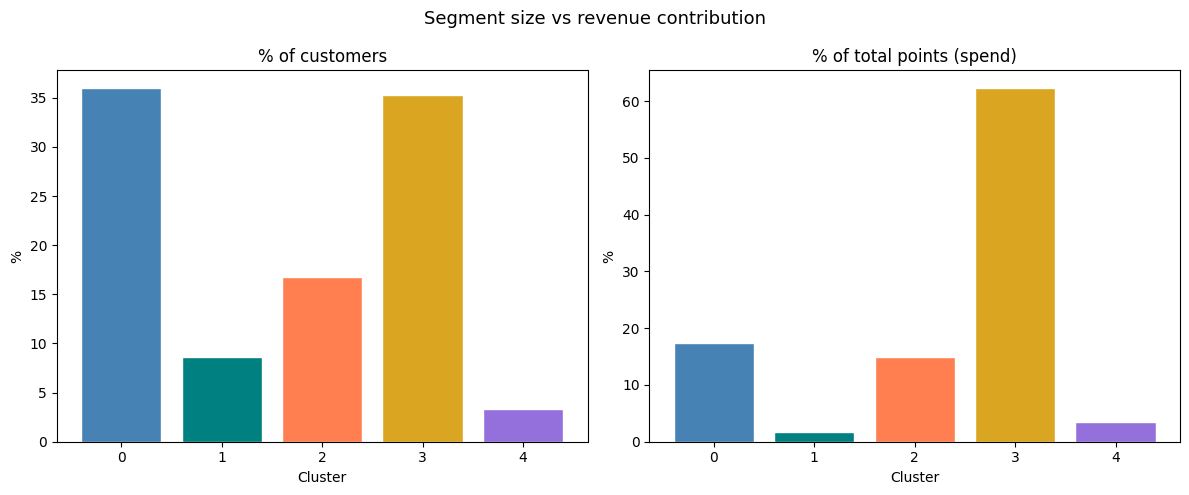


── Revenue share per segment ──
  Cluster 0: 36.0% of customers  |  17.4% of spend
  Cluster 1: 8.6% of customers  |  1.8% of spend
  Cluster 2: 16.8% of customers  |  15.0% of spend
  Cluster 3: 35.3% of customers  |  62.3% of spend
  Cluster 4: 3.3% of customers  |  3.5% of spend


In [74]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  6.1 Segment size
size = customer_df.groupby('cluster_label').size().reset_index(name='n_customers')
size['pct'] = (size['n_customers'] / size['n_customers'].sum() * 100).round(1)
print("── Segment sizes ──")
print(size.to_string(index=False))

#  6.2 Mean profile per segment (log-transformed scale as original were dropped)
# Updated profile_cols to use existing (log-transformed) metrics
profile_cols = [
    'recency', 'outlet_hhi', 'avg_promo_share',
    'total_points_log', 'frequency_log', 'avg_ticket_log'
]

profile = customer_df.groupby('cluster_label')[profile_cols].mean().round(2)
print("\n── Segment mean profiles (log-transformed scale) ──") # Adjusted description
print(profile.T)  # transposed so metrics are rows, segments are columns

#  6.3 Radar / spider chart — one line per segment
from matplotlib.patches import FancyArrowPatch
from math import pi

# Normalise profile to 0-1 for radar
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

categories = profile_cols
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['steelblue', 'teal', 'coral', 'goldenrod', 'mediumpurple']

for i, row in profile_norm.iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {i}', color=colors[i])
    ax.fill(angles, values, alpha=0.07, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_title('Segment profiles — radar chart', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

#  6.4 Heatmap of segment profiles
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    profile_norm.T,
    annot=profile.T,       # show log-transformed values in cells
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Segment profile heatmap (colour = normalised, value = log-transformed)', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Metric')
plt.tight_layout()
plt.show()

#  6.5 Box plots — distribution within each segment
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Metric distributions by segment', fontsize=13)

# Updated plot_metrics to use existing (log-transformed) metrics
plot_metrics = [
    ('total_points_log',    'Total points (log)'),
    ('frequency_log',       'Frequency (visits) (log)'),
    ('recency',             'Recency (days)'),
    ('avg_ticket_log',      'Avg ticket (log)'),
    ('outlet_hhi',          'Outlet concentration (HHI)'),
    ('avg_promo_share',     'Promo share'),
]

for ax, (col, label) in zip(axes.flatten(), plot_metrics):
    customer_df.boxplot(
        column=col, by='cluster_label',
        ax=ax, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2)
    )
    ax.set_title(label)
    ax.set_xlabel('Cluster')
    plt.sca(ax)
    plt.title(label)

plt.suptitle('')
plt.tight_layout()
plt.show()

#  6.6 Revenue share per segment
# Use the 'revenue_by_cluster' stored before dropping 'total_points'
revenue = revenue_by_cluster
revenue_pct = (revenue / revenue.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Segment size vs revenue contribution', fontsize=13)

axes[0].bar(size['cluster_label'], size['pct'], color=colors, edgecolor='white')
axes[0].set_title('% of customers')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('%')

axes[1].bar(revenue_pct.index, revenue_pct.values, color=colors, edgecolor='white')
axes[1].set_title('% of total points (spend)') # Now refers to actual spend
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

print("\n── Revenue share per segment ──")
for i in revenue_pct.index:
    print(f"  Cluster {i}: {size.loc[size['cluster_label']==i, 'pct'].values[0]}% of customers  |  "
          f"{revenue_pct[i]}% of spend") # Now refers to actual spend

### 6.7 Segment Naming

We map cluster numbers to business-readable segment names based on the
profile analysis above.

| Cluster | Segment Name | Key characteristic |
|---|---|---|
| 0 | Light Buyers | Regular visits, low basket |
| 1 | Lapsed / At-Risk | ~6 months inactive |
| 2 | Engaged Mid-Tier | Solid behaviour, upsell potential |
| 3 | Champions | High frequency, high spend, recent |
| 4 | High Value Occasionals | Infrequent but highest avg ticket |

In [76]:
segment_names = {
    0: 'Light Buyers',
    1: 'Lapsed / At-Risk',
    2: 'Engaged Mid-Tier',
    3: 'Champions',
    4: 'High Value Occasionals'
}

customer_df['segment_name'] = customer_df['cluster_label'].map(segment_names)
print(customer_df[['CUSTOMER_ID', 'cluster_label', 'segment_name']].head(10))

  CUSTOMER_ID  cluster_label      segment_name
0  AA00312188              2  Engaged Mid-Tier
1  AA00312390              0      Light Buyers
2  AA00325975              3         Champions
3  AA00336843              2  Engaged Mid-Tier
4  AA00339761              0      Light Buyers
5  AA00339963              3         Champions
6  AA00353548              0      Light Buyers
7  AA00361699              0      Light Buyers
8  AA00367334              3         Champions
9  AA00395109              3         Champions


## 7. Campaign Briefs

Based on the segmentation results, the following targeted communication briefs
are defined for each segment.

---

###  Cluster 3 - Champions
*35% of customers | 62% of revenue*

- **Objective:** Retain and reward. These are your most valuable customers —
the priority is keeping them engaged and preventing churn.
- **Tone:** Exclusive, appreciative. Make them feel recognised and valued.
- **Offer type:** Loyalty rewards, early access to new products, VIP promotions,
personalised thank-you offers.
- **Channel:** Email + push notification.
- **Frequency:** Twice a month — enough to stay top of mind without overexposing.

---

###  Cluster 4 - High Value Occasionals
*3.3% of customers | 3.5% of revenue*

- **Objective:** Increase visit frequency. They spend big when they come —
the goal is to bring them in more often.
- **Tone:** Premium, personalised. Speak to their high-spend behaviour.
- **Offer type:** Time-limited offers, "we miss you" incentives tied to
high-value categories they've purchased before.
- **Channel:** Email.
- **Frequency:** Once a month — they are low frequency by nature,
don't overwhelm them.

---

###  Cluster 2 - Engaged Mid-Tier
*17% of customers | 15% of revenue*

- **Objective:** Upsell and upgrade. Push them towards Champion behaviour
by increasing basket size and category breadth.
- **Tone:** Encouraging, helpful. Position the brand as making their
shopping experience better.
- **Offer type:** Cross-category promotions, bundle deals,
points multiplier events to reward increased spend.
- **Channel:** Email + push notification.
- **Frequency:** Twice a month.

---

###  Cluster 0 - Light Buyers
*36% of customers | 17% of revenue*

- **Objective:** Basket building. Largest segment by headcount but low spend —
even a small increase in average ticket has significant revenue impact at scale.
- **Tone:** Friendly, discovery-focused. Introduce them to categories
they haven't tried yet.
- **Offer type:** Category introduction offers, multi-buy promotions,
low-threshold points bonuses to reward slightly larger baskets.
- **Channel:** Email + push notification.
- **Frequency:** Once a month — avoid over-communicating to a low-engagement group.

---

###  Cluster 1 - Lapsed / At-Risk
*8.6% of customers | 1.8% of revenue*

- **Objective:** Win-back. Last purchase was ~6 months ago —
these customers are drifting away and need a strong reason to return.
- **Tone:** Direct, urgent. Acknowledge the gap and offer a clear incentive.
- **Offer type:** Win-back discount, "we haven't seen you in a while"
personalised offer, high-value one-time coupon to trigger a return visit.
- **Channel:** Email — the most direct channel for re-engagement.
- **Frequency:** A short win-back sequence of 2-3 communications
over 4 weeks, then move unresponsive customers to a dormant list.

---

### Summary Table

| Segment | Customers | Revenue Share | Key Characteristic |
|---|---|---|---|
| Champions | 35% | 62% | High frequency, high spend, recent |
| High Value Occasionals | 3% | 4% | Rare visits but highest avg ticket |
| Engaged Mid-Tier | 17% | 15% | Solid behaviour, upsell potential |
| Light Buyers | 36% | 17% | Regular visits but low basket size |
| Lapsed / At-Risk | 9% | 2% | ~6 months inactive, drifting away |

## 8. Conclusion

This project delivered a data-driven segmentation of the Italian subsidiary's
customer base using ~2 years of transactional data across 25,727 registered
customers and 2 million+ receipt lines.

### Key Findings

After data cleaning, feature engineering, and k-means clustering (k=5),
five distinct customer segments were identified:

| Segment | Customers | Revenue Share | Key Characteristic |
|---|---|---|---|
| Champions | 35% | 62% | High frequency, high spend, recent |
| High Value Occasionals | 3% | 4% | Rare visits but highest avg ticket |
| Engaged Mid-Tier | 17% | 15% | Solid behaviour, upsell potential |
| Light Buyers | 36% | 17% | Regular visits but low basket size |
| Lapsed / At-Risk | 9% | 2% | ~6 months inactive, drifting away |

### Critical Insight

Champions represent just 35% of the customer base but generate 62% of total
revenue. Protecting this group through retention and reward programmes is the
single highest-priority CRM action.

### Recommendations

- **Retain** Champions with exclusive loyalty rewards and personalised communication
- **Upgrade** Engaged Mid-Tier and Light Buyers through upsell and basket-building campaigns
- **Reactivate** Lapsed customers with a targeted 4-week win-back sequence
- **Convert** High Value Occasionals from occasional to regular shoppers through
frequency-building incentives

### Performance Measure

Segmentation effectiveness should be tracked monthly using three KPIs:
1. **Segment migration rate** — share of customers moving to a higher-value segment
2. **Revenue per segment** — monthly points/spend tracked per group
3. **Campaign uplift** — response rate of targeted segment vs control group